In [1]:
1

1

may 19

Cell 1: System Setup & Imports
This cell links the notebook to your isolated modules and loads the libraries.

In [5]:
import os
import sys
import numpy as np
import pandas as pd
import time

print("--- STEP 1: SYSTEM SETUP ---")
# Get the directory where the notebook is located (validation_code)
CURRENT_DIR = os.getcwd()
# Go one level up to find the 'api' folder
API_DIR = os.path.dirname(CURRENT_DIR) 

SERVICES_DIR = os.path.join(API_DIR, "services")

# THE FIX: Add the 'api' folder ITSELF to the Python path
if API_DIR not in sys.path: 
    sys.path.append(API_DIR)

# Add services folder so it can find the .dta files later
if SERVICES_DIR not in sys.path: 
    sys.path.append(SERVICES_DIR)

try:
    from ecd_nested_simulation_functions import generate_ecd_dummy_data
    from ecd_nested_simulation_functions import ecd_sampling_strategy
    print("✅ System paths registered.")
    print("✅ ECD Simulation modules imported successfully.\n")
except ImportError as e:
    print(f"❌ IMPORT ERROR: {e}")

--- STEP 1: SYSTEM SETUP ---
✅ System paths registered.
✅ ECD Simulation modules imported successfully.



Cell 2: Load WHO Biological Standards
This verifies that the .dta files are being read correctly from your services folder.

In [4]:
print("--- STEP 2: LOAD WHO STANDARDS ---")
def extract_data_from_dta(filename):
    file_path = os.path.join(SERVICES_DIR, filename)
    return pd.read_stata(file_path)

haz_params = extract_data_from_dta('lenanthro.dta')
waz_params = extract_data_from_dta('weianthro.dta')
whz_params_lying = extract_data_from_dta('wflanthro.dta')
whz_params_standing = extract_data_from_dta('wfhanthro.dta')

print("✅ WHO Standards Loaded Successfully.")
print(f"HAZ parameters shape: {haz_params.shape}\n")
display(haz_params.head(3)) # Visually verify the data

--- STEP 2: LOAD WHO STANDARDS ---
✅ WHO Standards Loaded Successfully.
HAZ parameters shape: (3714, 6)



,__000001,_agedays,l,m,s,loh
0,1,0,1,49.884201,0.03795,L
1,1,1,1,50.060101,0.03785,L
2,1,2,1,50.235901,0.03775,L


Cell 3: Generate the Synthetic Universe
This cell generates a scaled-down population so you can quickly test the math without waiting minutes.

In [8]:
print("--- STEP 3: GENERATE SYNTHETIC UNIVERSE ---")
N_L1S = 5       # Scaled down for rapid testing (normally 334)
N_L0S = 5       # Scaled down for rapid testing (normally 25)
N_CHILDREN = 5

common_real_params = {
    'girl_ratio': 0.5, 'min_age': 0, 'max_age': 1790, 'num_timepoints': 1, 'time_lags': [],
    'percent_stunting': 35, 'percent_underweight': 33, 'rho': 0.7
}

# Simulating a "Corrupt Collusion" Preset
L0_params_list, L1_params_list, L2_params_dict = generate_ecd_dummy_data.generate_nested_distortion_parameters(
    n_L1s=N_L1S, n_L0s_per_L1=N_L0S,
    real_percent_stunting=35, real_percent_underweight=33,
    mean_percent_under_reporting_stunting=30, mean_percent_under_reporting_underweight=30, 
    mean_bunch_factor_haz=0.25, mean_bunch_factor_waz=0.25, mean_bunch_factor_whz=0.25,
    mean_percent_copy=60, mean_collusion_index=0.90,
    sd_across_units_percent_under_reporting_stunting=2.0, sd_across_units_percent_under_reporting_underweight=2.0,
    sd_within_units_percent_under_reporting_stunting=1.0, sd_within_units_percent_under_reporting_underweight=1.0,
    sd_across_units_bunch_factor_haz=0.01, sd_across_units_bunch_factor_waz=0.01, sd_across_units_bunch_factor_whz=0.01,
    sd_within_units_bunch_factor_haz=0.01, sd_within_units_bunch_factor_waz=0.01, sd_within_units_bunch_factor_whz=0.01,
    sd_percent_copy=2.0, sd_collusion_index=0.02,
    error_sd_height_all_L0s=0.0, error_sd_weight_all_L0s=0.00,
    error_sd_height_L1=0.0, error_sd_weight_L1=0.00, 
    error_sd_height_L2=0.0, error_sd_weight_L2=0.00, 
    mean_time_lag_L1=15, mean_time_lag_L2=30
)

np.random.seed(42)
start = time.time()
nested_measurements = generate_ecd_dummy_data.generate_nested_measurements(
    real_params=common_real_params, L0_params_list=L0_params_list, L1_params_list=L1_params_list, L2_params_dict=L2_params_dict,
    n_L1s=N_L1S, n_L0s_per_L1=N_L0S, n_children_per_L0=N_CHILDREN, n_children_L1=N_CHILDREN, n_children_L2=N_CHILDREN,
    haz_params=haz_params, waz_params=waz_params, whz_params_lying=whz_params_lying, whz_params_standing=whz_params_standing, make_plots=False
)
print(f"✅ Synthetic Generation complete in {round(time.time()-start, 2)} seconds.\n")

--- STEP 3: GENERATE SYNTHETIC UNIVERSE ---


Assigning Personalities: 100%|██████████| 5/5 [00:00<?, ?it/s]


✅ Synthetic Generation complete in 3.39 seconds.



Cell 4: Data Flattening & Error Calculations
This flattens the nested dictionary into a readable Pandas DataFrame.

In [9]:
print("--- STEP 4: FLATTEN NESTED DATA ---")
all_children = []

for L1_id, L1_data in nested_measurements.items():
    if L1_id == 'metadata': continue
    for L0_id, L0_data in L1_data.items():
        if L0_id == 'L1_info': continue
        
        df_real = L0_data['real']['data'].copy().rename(columns={'haz': 'real_haz'})
        df_L0 = L0_data['L0']['data'].copy().rename(columns={'haz': 'L0_haz'})
        df_L1 = L0_data['L1']['data'].copy().rename(columns={'haz': 'L1_haz'})
        df_L2 = L0_data['L2']['data'].copy().rename(columns={'haz': 'L2_haz'})
        
        merged = df_real[['child_id', 'real_haz']].merge(
            df_L0[['child_id', 'L0_haz']], on='child_id', how='left').merge(
            df_L1[['child_id', 'L1_haz']], on='child_id', how='left').merge(
            df_L2[['child_id', 'L2_haz']], on='child_id', how='left')
            
        merged['L1_id'] = L1_id
        merged['L0_id'] = L0_id
        all_children.append(merged)

df_pop = pd.concat(all_children, ignore_index=True)

# Calculate individual errors
df_pop['L0_Error'] = np.abs(df_pop['L0_haz'] - df_pop['real_haz'])
df_pop['L1_Error'] = np.abs(df_pop['L1_haz'] - df_pop['L0_haz'])

print(f"✅ Flattening complete. Total children generated: {len(df_pop)}")
display(df_pop.head())

--- STEP 4: FLATTEN NESTED DATA ---
✅ Flattening complete. Total children generated: 125


,child_id,real_haz,L0_haz,L1_haz,L2_haz,L1_id,L0_id,L0_Error,L1_Error
0,L1_0_L0_0_child_0,-0.638898,-0.638898,-0.638898,-0.638898,L1_0,L0_0,9.992007e-16,1.665335e-15
1,L1_0_L0_0_child_1,-1.233308,-1.233308,-1.317069,-1.233308,L1_0,L0_0,1.332268e-15,8.376171e-02
2,L1_0_L0_0_child_2,-1.875282,-1.875282,-1.983216,-1.875282,L1_0,L0_0,4.440892e-16,1.079342e-01
3,L1_0_L0_0_child_3,-3.558867,-1.002671,-3.558867,-3.558867,L1_0,L0_0,2.556196e+00,2.556196e+00
4,L1_0_L0_0_child_4,0.400353,0.400353,0.278471,0.400353,L1_0,L0_0,1.332268e-15,1.218818e-01


Cell 5: Strategy Calculation Engine
This is where the magic happens: calculating the "God Mode" truth, running L1's limited sample, and seeing how accurate L1 is.

In [10]:
print("--- STEP 5: STRATEGY CALCULATION ENGINE ---")

def calculate_metrics(df, group_cols, col_meas, col_baseline):
    temp = df.copy()
    temp['_err'] = np.abs(temp[col_meas] - temp[col_baseline])
    return temp.groupby(group_cols).agg(MAE=('_err', 'mean')).reset_index()

TARGET_L1_COUNT = max(1, int(N_L1S * 0.30)) # Target worst 30%
print(f"Goal: Catch the top {TARGET_L1_COUNT} worst L1 Supervisors.")

# 1. GOD MODE: The absolute truth
god_l1 = calculate_metrics(df_pop, ['L1_id'], 'L0_haz', 'real_haz')
god_l1_mae = set(god_l1.sort_values(by='MAE', ascending=False).head(TARGET_L1_COUNT)['L1_id'])
print(f"God Mode Worst L1s (Top 3): {list(god_l1_mae)[:3]}...")

# 2. L1 Sampling
L1_BUDGET_PCT = 0.40 # Testing a 40% Budget
TOTAL_KIDS = N_L0S * N_CHILDREN
budget_k = int(TOTAL_KIDS * L1_BUDGET_PCT)

# Balanced strategy: e.g., 5 clinics x 12 kids = 60 kids (40% of 150)
l1_c, l1_k = min(5, N_L0S), min(12, N_CHILDREN)
print(f"\n--- Testing L1 Strategy: {l1_c} Clinics x {l1_k} Kids ({L1_BUDGET_PCT*100}% Budget) ---")

# Execute Bulletproof Sampling
l1_clinics = df_pop[['L1_id', 'L0_id']].drop_duplicates().groupby('L1_id').apply(
    lambda x: x.sample(n=min(len(x), l1_c), replace=False)).reset_index(drop=True)

df_l1_sheet = df_pop.merge(l1_clinics, on=['L1_id', 'L0_id']).groupby(['L1_id', 'L0_id']).apply(
    lambda x: x.sample(n=min(len(x), l1_k), replace=False)).reset_index(drop=True)

print(f"L1 successfully sampled {len(df_l1_sheet)} total kids across the region.")

l1_diagnosis = calculate_metrics(df_l1_sheet, ['L1_id'], 'L1_haz', 'L0_haz')
l1_caught = set(l1_diagnosis.sort_values(by='MAE', ascending=False).head(TARGET_L1_COUNT)['L1_id'])
v1_acc = (len(l1_caught & god_l1_mae) / TARGET_L1_COUNT) * 100

print(f"👉 L1 Ranking Accuracy: {round(v1_acc, 1)}%")

--- STEP 5: STRATEGY CALCULATION ENGINE ---
Goal: Catch the top 1 worst L1 Supervisors.
God Mode Worst L1s (Top 3): ['L1_0']...

--- Testing L1 Strategy: 5 Clinics x 5 Kids (40.0% Budget) ---
L1 successfully sampled 125 total kids across the region.
👉 L1 Ranking Accuracy: 100.0%


Cell 6: L2 Auditing Validation
This proves L2's ability to catch corrupt L1s using a limited sample.

In [11]:
# 3. L2 Auditing
L2_BUDGET_PCT = 0.50 # L2 audits 50% of L1's sheet
l2_c, l2_k = min(3, l1_c), min(10, l1_k)
print(f"\n--- Testing L2 Execution: {l2_c} Clinics x {l2_k} Kids ---")

df_l2_audit = df_l1_sheet.groupby('L1_id').apply(
    lambda x: x.sample(n=min(len(x), l2_c * l2_k), replace=False)).reset_index(drop=True)

sheet_truth = calculate_metrics(df_l1_sheet, ['L1_id'], 'L1_haz', 'real_haz')
sheet_mae = set(sheet_truth.sort_values(by='MAE', ascending=False).head(TARGET_L1_COUNT)['L1_id'])

l2_diagnosis = calculate_metrics(df_l2_audit, ['L1_id'], 'L2_haz', 'L1_haz')
l2_caught = set(l2_diagnosis.sort_values(by='MAE', ascending=False).head(TARGET_L1_COUNT)['L1_id'])
v3_acc = (len(l2_caught & sheet_mae) / TARGET_L1_COUNT) * 100

print(f"👉 L2 Ranking Accuracy (Catching corrupt L1s): {round(v3_acc, 1)}%")
print("\n✅ VALIDATION COMPLETE.")


--- Testing L2 Execution: 3 Clinics x 5 Kids ---
👉 L2 Ranking Accuracy (Catching corrupt L1s): 100.0%

✅ VALIDATION COMPLETE.


apr 23 mock data run

📁 All files for this round will be saved in: 
C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\run_20260523_173642

🚀 Step 1: Generating physical universe...


Assigning Personalities: 100%|██████████| 5/5 [00:00<00:00, 503.95it/s]


⚙️ Step 2: Running Tracer Combinations & MAE...

📊 Step 3: Rendering Plots...


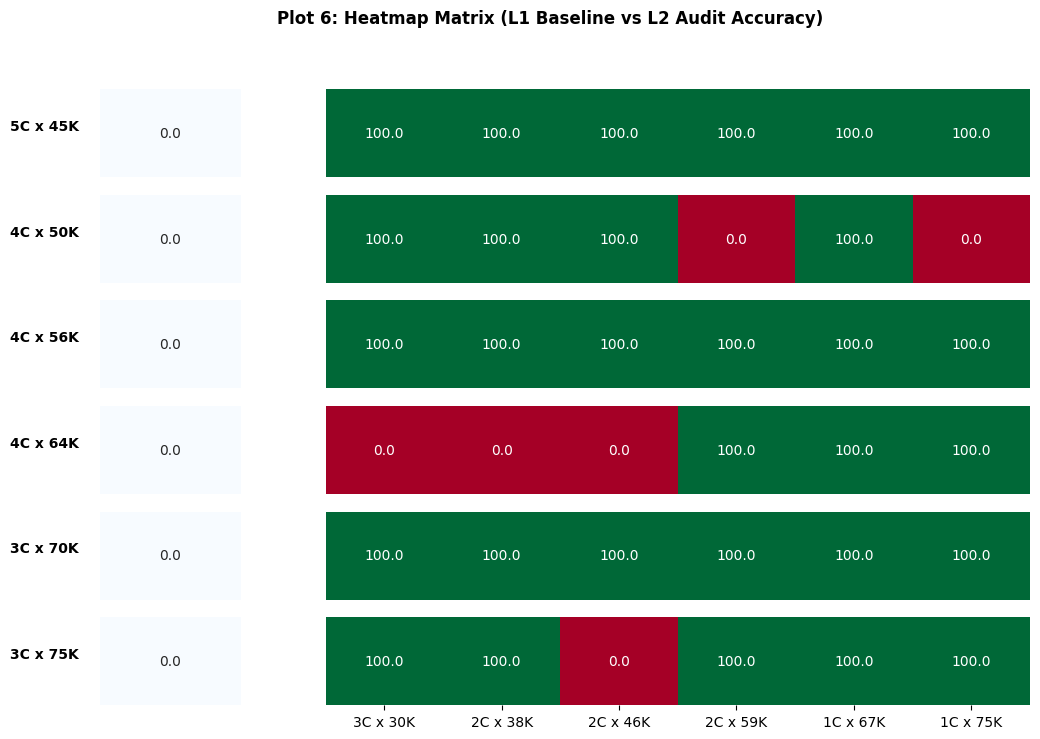

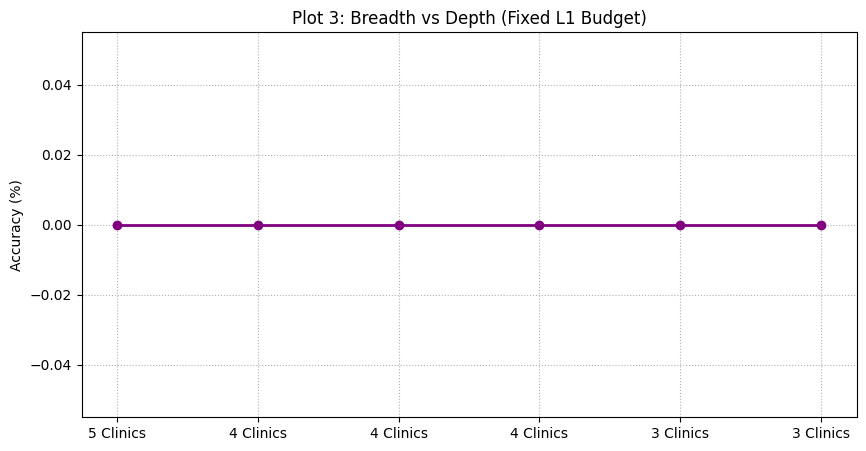

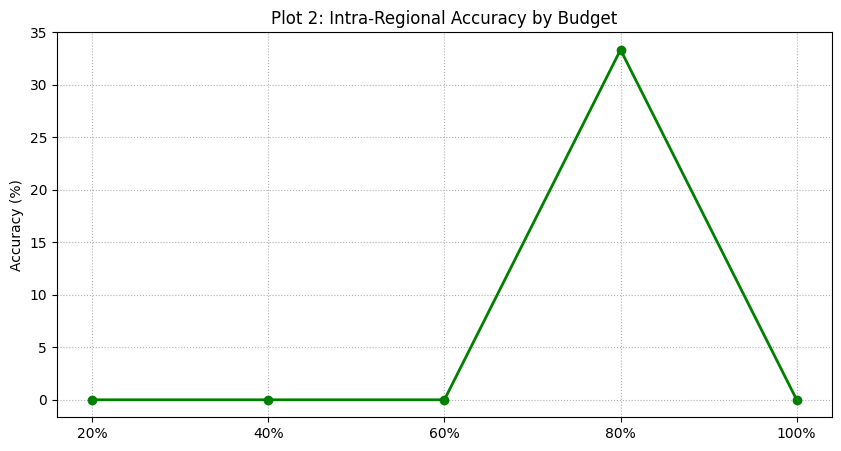

✅ Round Complete! Check C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\run_20260523_173642 for your saved Parquet and CSV files.


In [10]:
import sys
import os
import datetime
import pandas as pd
import matplotlib.pyplot as plt
import importlib

# 1. LINK TO YOUR EXACT DIRECTORIES
services_path = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\api\services"
utils_path = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\dashboard\src\utils\intervention_design"

# Tell Python to look in both folders
if services_path not in sys.path:
    sys.path.append(services_path)
if utils_path not in sys.path:
    sys.path.append(utils_path)

# Import the modules
import data_generator
import metrics_calculator
import plotting_engine  

# ---------------------------------------------------------
# Force Python to reload the modules from disk
# ---------------------------------------------------------
importlib.reload(data_generator)
importlib.reload(metrics_calculator)
importlib.reload(plotting_engine)
# ---------------------------------------------------------

# 2. CREATE A UNIQUE FOLDER FOR THIS SPECIFIC RUN
base_output_dir = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs"
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
run_output_dir = os.path.join(base_output_dir, f"run_{timestamp}")

if not os.path.exists(run_output_dir):
    os.makedirs(run_output_dir)

print(f"📁 All files for this round will be saved in: \n{run_output_dir}")

# 3. SET YOUR INPUTS FOR THIS ROUND
params = {
    "n_L1s": 5,                
    "n_L0s_per_L1": 25,         
    "n_children_per_L0": 15,    
    "l1_corruption_pct": 0.05,  
    "l0_fraud_pct": 0.05,       
    "collusion_factor": 0.10,   
    "copy_paste_pct": 5,        
    "equipment_error": 0.1,     
    "target_percentile": 0.30   # Target the worst 30%
}

task_id = f"sim_{timestamp}"

# 4. RUN THE PIPELINE 
print("\n🚀 Step 1: Generating physical universe...")
child_path, df_pop = data_generator.build_universe(params, task_id, run_output_dir)

print("⚙️ Step 2: Running Tracer Combinations & MAE...")
strategy_path = metrics_calculator.run_tracer_engine(df_pop, task_id, run_output_dir, target_percentile=params["target_percentile"])

# 5. DISPLAY THE RESULTS 
print("\n📊 Step 3: Rendering Plots...")
strategy_df = pd.read_csv(strategy_path)

# Plot 6: Heatmap Matrix
fig6 = plotting_engine.plot_6_heatmap(strategy_df[(strategy_df['L1_Budget_Pct'] == '60%') & (strategy_df['L2_Budget_Pct'] == '40%')])
plt.show()

# Plot 3: Breadth vs Depth
fig3 = plotting_engine.plot_3_breadth_depth(strategy_df[strategy_df['L1_Budget_Pct'] == '60%'])
plt.show()

# Plot 2: Intra-Regional Accuracy
fig2 = plotting_engine.plot_2_intra_regional(strategy_df)
plt.show()

print(f"✅ Round Complete! Check {run_output_dir} for your saved Parquet and CSV files.")

bboth  w


🚀 Step 1: Generating physical universe (L2 Present: Yes)...


Assigning Personalities: 100%|██████████| 5/5 [00:00<?, ?it/s]


⚙️ Step 2: Running Tracer Combinations & MAE for ['Height', 'Weight']...

📊 Step 3: Rendering Plots sequentially...

   RENDERING DASHBOARD FOR: HEIGHT
   Filters Active -> L1: 60% | L2: 40%


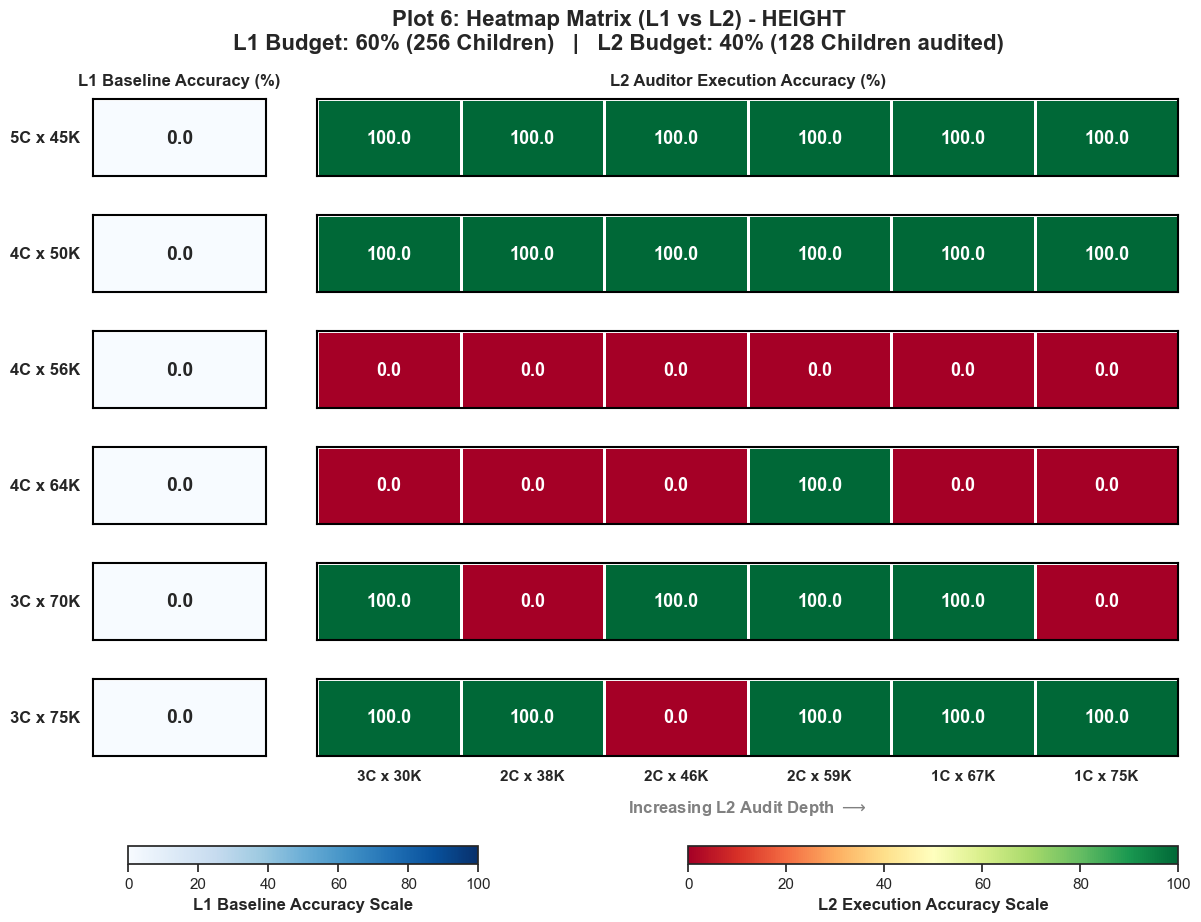

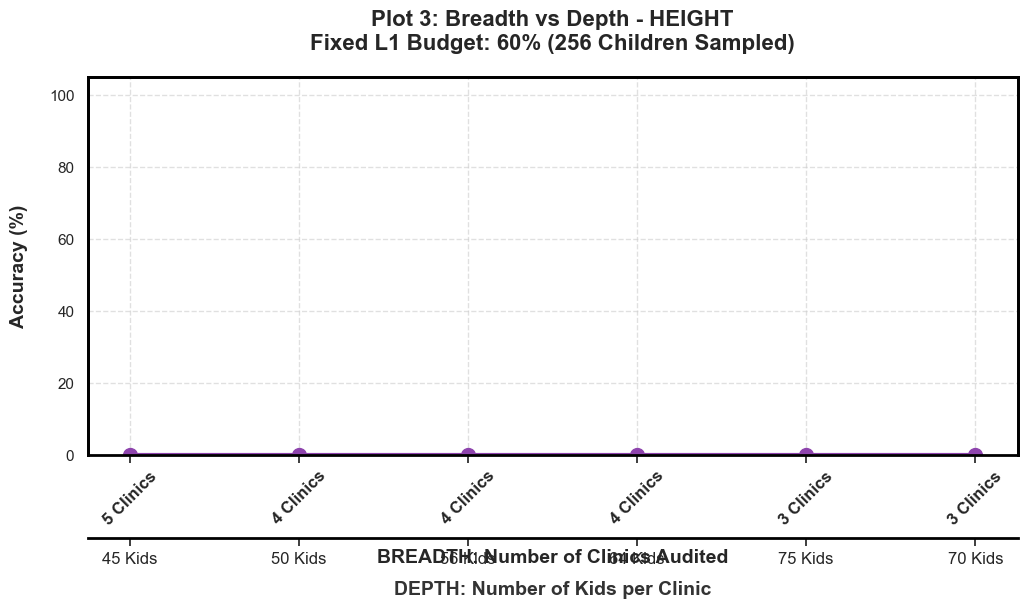

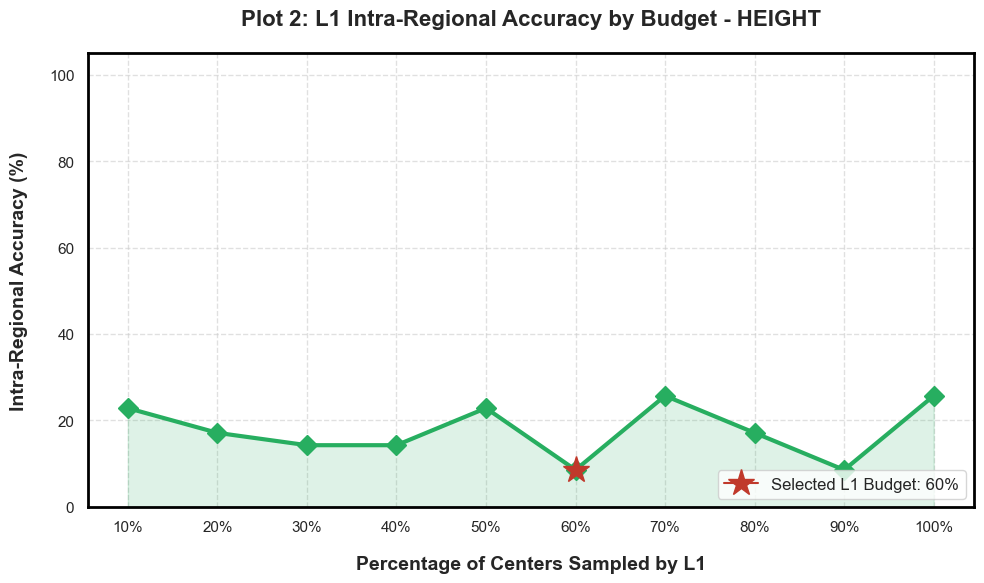


   RENDERING DASHBOARD FOR: WEIGHT
   Filters Active -> L1: 60% | L2: 40%


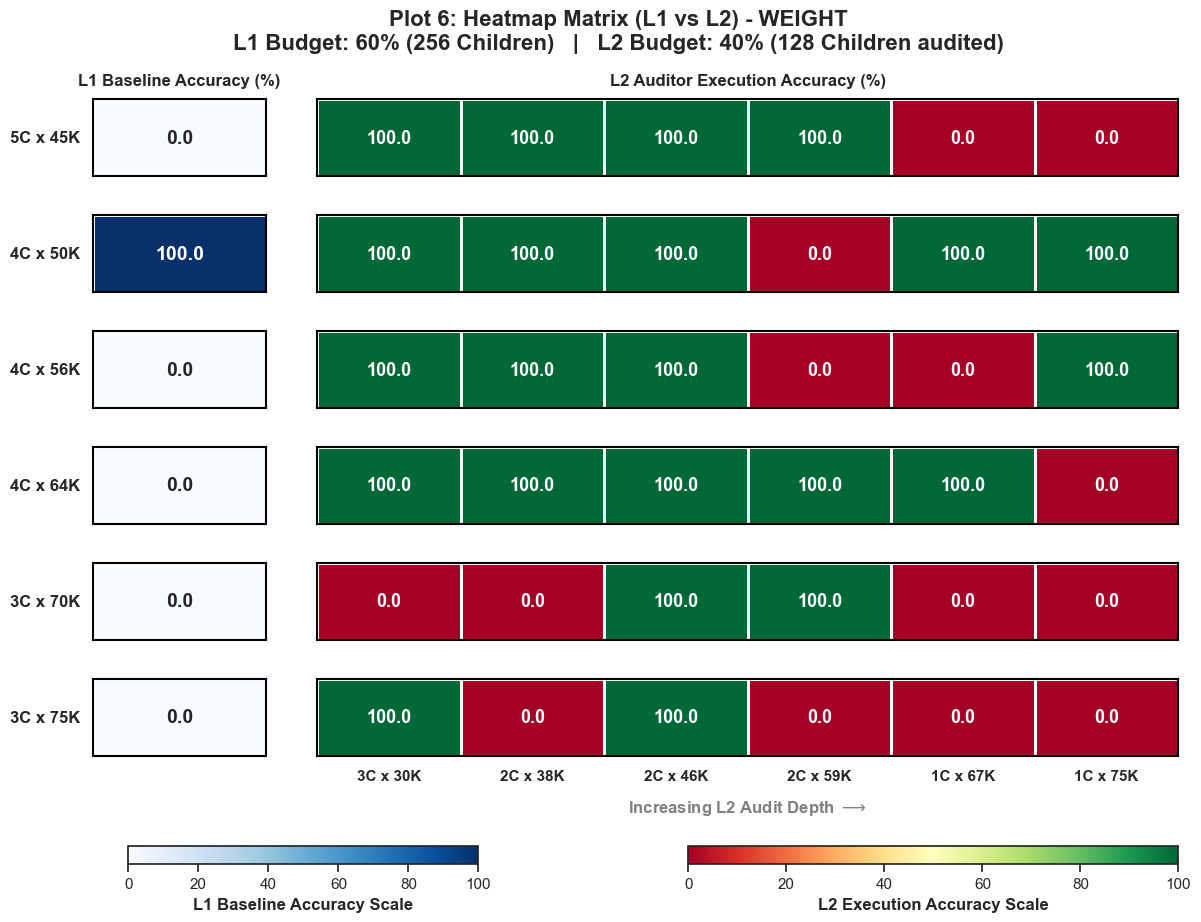

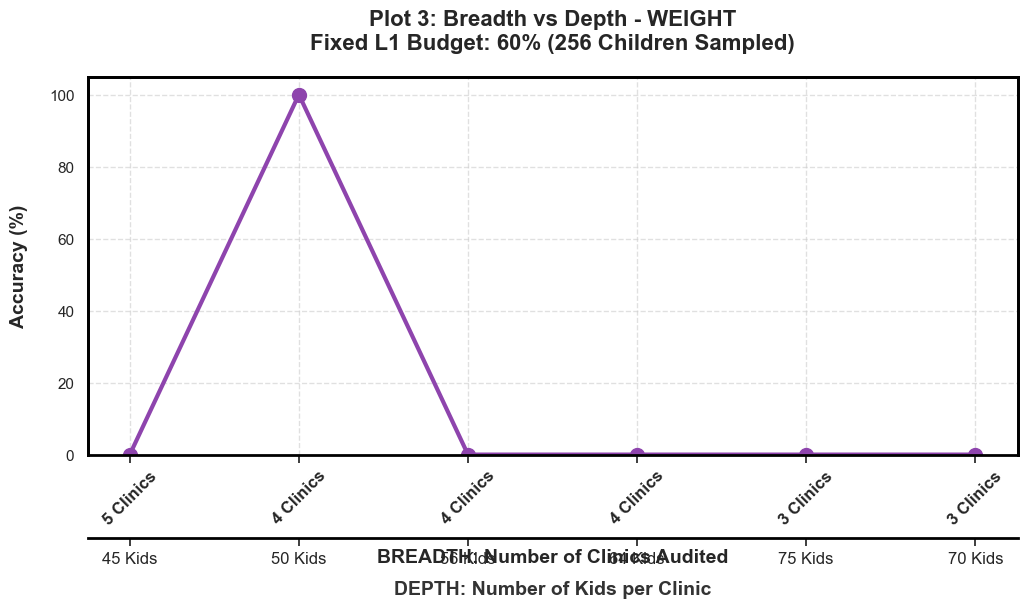

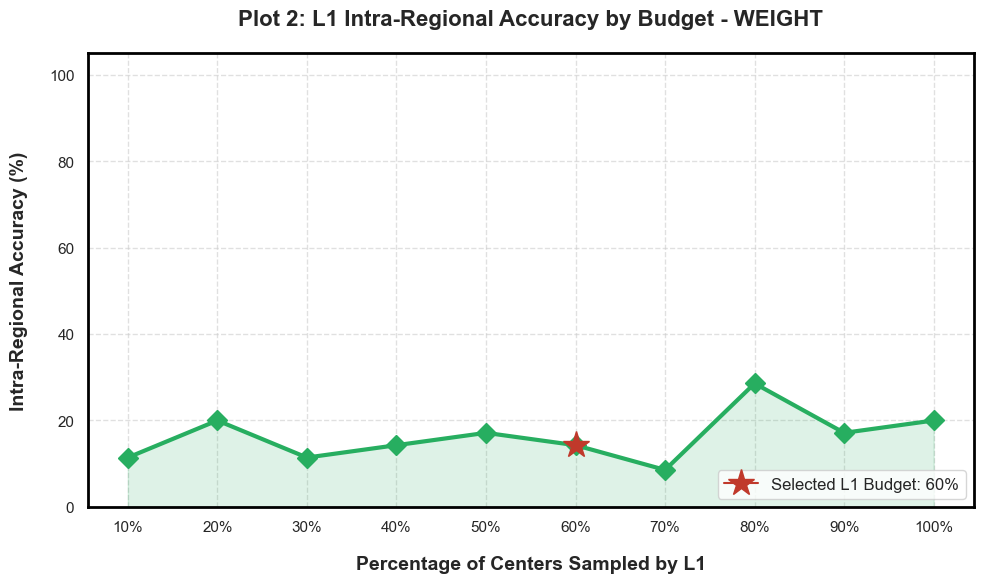


✅ Round Complete! Check C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\run_20260523_195114 for saved files.


In [17]:
import sys
import os
import datetime
import pandas as pd
import matplotlib.pyplot as plt
import importlib

# 1. LINK TO DIRECTORIES
services_path = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\api\services"
utils_path = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\dashboard\src\utils\intervention_design"

if services_path not in sys.path: sys.path.append(services_path)
if utils_path not in sys.path: sys.path.append(utils_path)

import data_generator
import metrics_calculator
import plotting_engine  

importlib.reload(data_generator)
importlib.reload(metrics_calculator)
importlib.reload(plotting_engine)

base_output_dir = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs"
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
run_output_dir = os.path.join(base_output_dir, f"run_{timestamp}")
if not os.path.exists(run_output_dir): os.makedirs(run_output_dir)

# ==============================================================================
# DASHBOARD FILTERS (Tweak these to change your plots dynamically!)
# ==============================================================================
params = {
    "has_l2": "Yes",            # "Yes" = Case 1 (Heatmap + All). "No" = Case 2 (No Heatmap)
    "n_L1s": 5,                
    "n_L0s_per_L1": 25,         
    "n_children_per_L0": 15,    
    "l1_corruption_pct": 0.05,  
    "l0_fraud_pct": 0.05,       
    "collusion_factor": 0.10,   
    "copy_paste_pct": 5,        
    "equipment_error": 0.1,     
    "target_percentile": 0.30,
    "output_variable": "both"   # "height", "weight", or "both"
}

UI_L1_BUDGET = "60%"            # Example: 10%, 20%, ... 100%
UI_L2_BUDGET = "40%"            # Example: 10%, 20%, ... 100%
# ==============================================================================

task_id = f"sim_{timestamp}"

# RUN THE PIPELINE 
print(f"\n🚀 Step 1: Generating physical universe (L2 Present: {params['has_l2']})...")
child_path, df_pop = data_generator.build_universe(params, task_id, run_output_dir)

if params["output_variable"].lower() == "both": target_inds = ["Height", "Weight"]
elif params["output_variable"].lower() == "weight": target_inds = ["Weight"]
else: target_inds = ["Height"]

print(f"⚙️ Step 2: Running Tracer Combinations & MAE for {target_inds}...")
strategy_path = metrics_calculator.run_tracer_engine(
    df_pop, task_id, run_output_dir, 
    target_percentile=params["target_percentile"], 
    indicators=target_inds,
    has_l2=params["has_l2"]  # <-- Passes the logic to skip L2 math if "No"
)

# DISPLAY RESULTS
print("\n📊 Step 3: Rendering Plots sequentially...")
strategy_df = pd.read_csv(strategy_path)

for ind in target_inds:
    print(f"\n" + "="*60)
    print(f"   RENDERING DASHBOARD FOR: {ind.upper()}")
    print(f"   Filters Active -> L1: {UI_L1_BUDGET} " + (f"| L2: {UI_L2_BUDGET}" if params["has_l2"] == "Yes" else "| L2: Not Present"))
    print("="*60)
    
    df_ind = strategy_df[strategy_df['Indicator'] == ind]
    
    # === CASE 1: L2 is Present ===
    if params["has_l2"].lower() == "yes":
        # Plot 6: Heatmap Matrix 
        df_filtered_p6 = df_ind[(df_ind['L1_Budget_Pct'] == UI_L1_BUDGET) & (df_ind['L2_Budget_Pct'] == UI_L2_BUDGET)]
        fig6 = plotting_engine.plot_6_heatmap(df_filtered_p6, l1_pct_str=UI_L1_BUDGET, l2_pct_str=UI_L2_BUDGET, indicator=ind)
        if fig6: plt.show()

    # === CASE 1 & CASE 2: L1 Plots always render ===
    # Plot 3: Breadth vs Depth (Fixed L1 Budget)
    df_filtered_p3 = df_ind[df_ind['L1_Budget_Pct'] == UI_L1_BUDGET]
    # In Case 2, we just take the first entry since L2 data is N/A
    if params["has_l2"].lower() == "no": df_filtered_p3 = df_filtered_p3.drop_duplicates(subset=['L1_Label'])
    fig3 = plotting_engine.plot_3_breadth_depth(df_filtered_p3, l1_pct_str=UI_L1_BUDGET, indicator=ind)
    if fig3: plt.show()

    # Plot 2: Intra-Regional Accuracy (Highlighting the selected L1 budget)
    df_filtered_p2 = df_ind.drop_duplicates(subset=['L1_Budget_Pct'])
    fig2 = plotting_engine.plot_2_intra_regional(df_filtered_p2, l1_pct_str=UI_L1_BUDGET, indicator=ind)
    if fig2: plt.show()

print(f"\n✅ Round Complete! Check {run_output_dir} for saved files.")

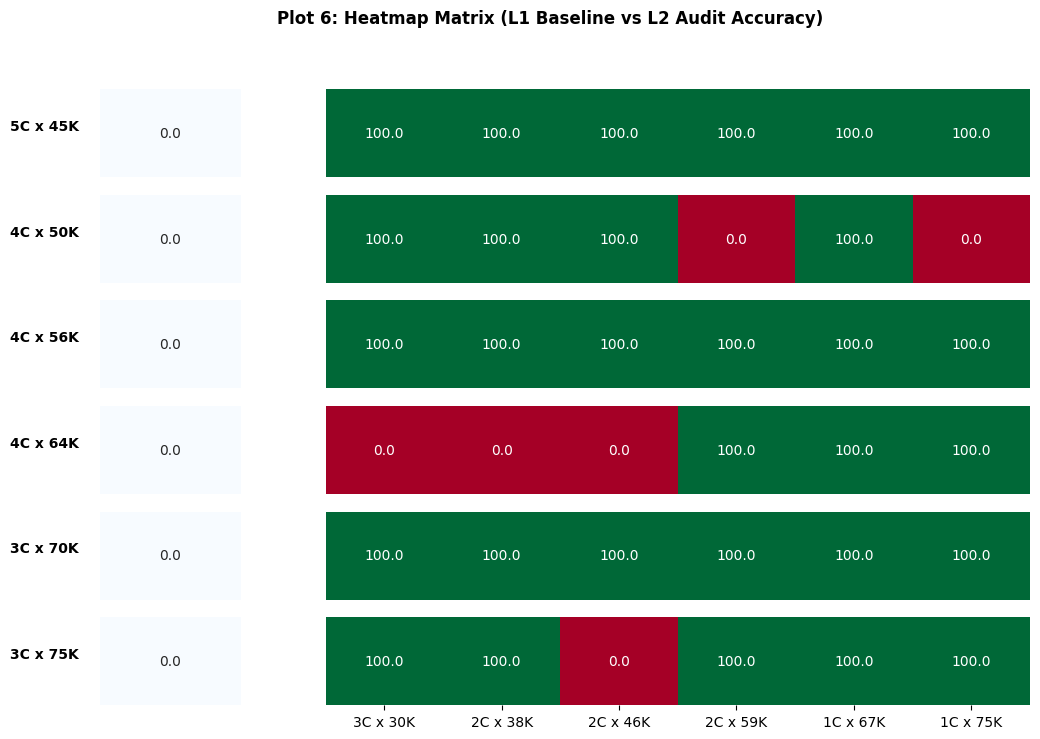

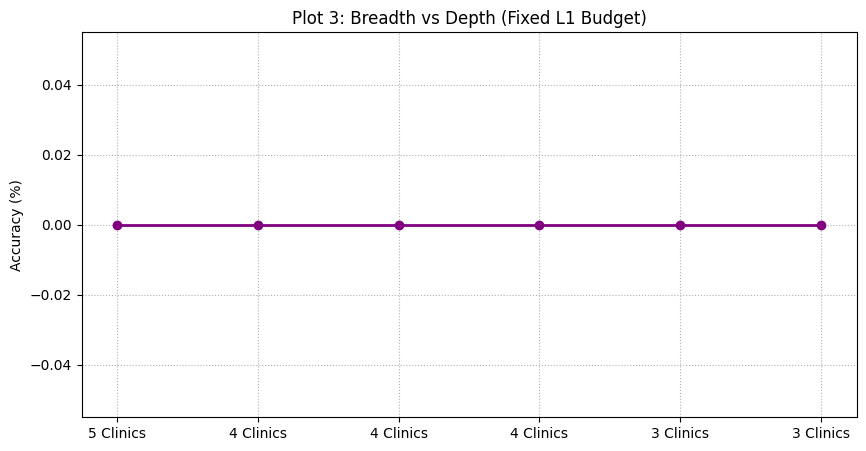

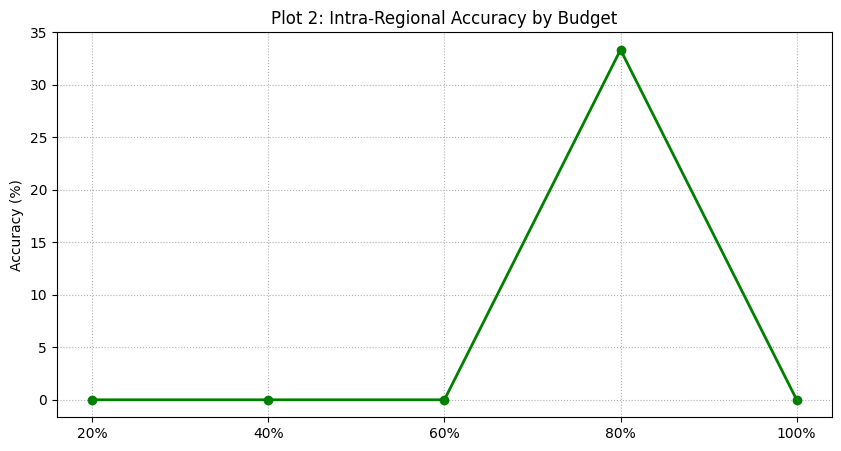

In [11]:
# Plot 6: Heatmap Matrix
fig6 = plotting_engine.plot_6_heatmap(strategy_df[(strategy_df['L1_Budget_Pct'] == '60%') & (strategy_df['L2_Budget_Pct'] == '40%')])
plt.show()

# Plot 3: Breadth vs Depth
fig3 = plotting_engine.plot_3_breadth_depth(strategy_df[strategy_df['L1_Budget_Pct'] == '60%'])
plt.show()

# Plot 2: Intra-Regional Accuracy
fig2 = plotting_engine.plot_2_intra_regional(strategy_df)
plt.show()

data sim alone

In [12]:
import sys
import os
import datetime
import pandas as pd
import matplotlib.pyplot as plt
import importlib

# 1. LINK TO YOUR EXACT DIRECTORIES
services_path = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\api\services"
utils_path = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\dashboard\src\utils\intervention_design"

# Tell Python to look in both folders
if services_path not in sys.path:
    sys.path.append(services_path)
if utils_path not in sys.path:
    sys.path.append(utils_path)

# Import the modules
import data_generator
import metrics_calculator
import plotting_engine  

# Force Python to reload the modules from disk
importlib.reload(data_generator)
importlib.reload(metrics_calculator)
importlib.reload(plotting_engine)

# 2. CREATE A UNIQUE FOLDER FOR THIS SPECIFIC RUN
base_output_dir = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs"
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
run_output_dir = os.path.join(base_output_dir, f"run_{timestamp}")

if not os.path.exists(run_output_dir):
    os.makedirs(run_output_dir)

print(f"📁 All files for this round will be saved in: \n{run_output_dir}")

# 3. SET YOUR INPUTS FOR THIS ROUND
params = {
    "n_L1s": 5,                
    "n_L0s_per_L1": 25,         
    "n_children_per_L0": 15,    
    "l1_corruption_pct": 0.05,  
    "l0_fraud_pct": 0.05,       
    "collusion_factor": 0.10,   
    "copy_paste_pct": 5,        
    "equipment_error": 0.1,     
    "target_percentile": 0.30   # Target the worst 30%
}

task_id = f"sim_{timestamp}"

# 4. GENERATE DATA
print("\n🚀 Step 1: Generating physical universe...")
child_path, df_pop = data_generator.build_universe(params, task_id, run_output_dir)
print("✅ Universe Generation Complete!")

📁 All files for this round will be saved in: 
C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\run_20260523_181324

🚀 Step 1: Generating physical universe...


Assigning Personalities: 100%|██████████| 5/5 [00:00<?, ?it/s]


✅ Universe Generation Complete!


part 2: calc

In [13]:
# 5. RUN CALCULATIONS
print("⚙️ Step 2: Running Tracer Combinations & MAE calculations...")

strategy_path = metrics_calculator.run_tracer_engine(
    df_pop, 
    task_id, 
    run_output_dir, 
    target_percentile=params["target_percentile"]
)

print(f"✅ Calculations Complete! Results saved to: {strategy_path}")

⚙️ Step 2: Running Tracer Combinations & MAE calculations...
✅ Calculations Complete! Results saved to: C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\run_20260523_181324\result_sim_20260523_181324.csv


part 3: plotting


📊 Step 3: Rendering Plots...


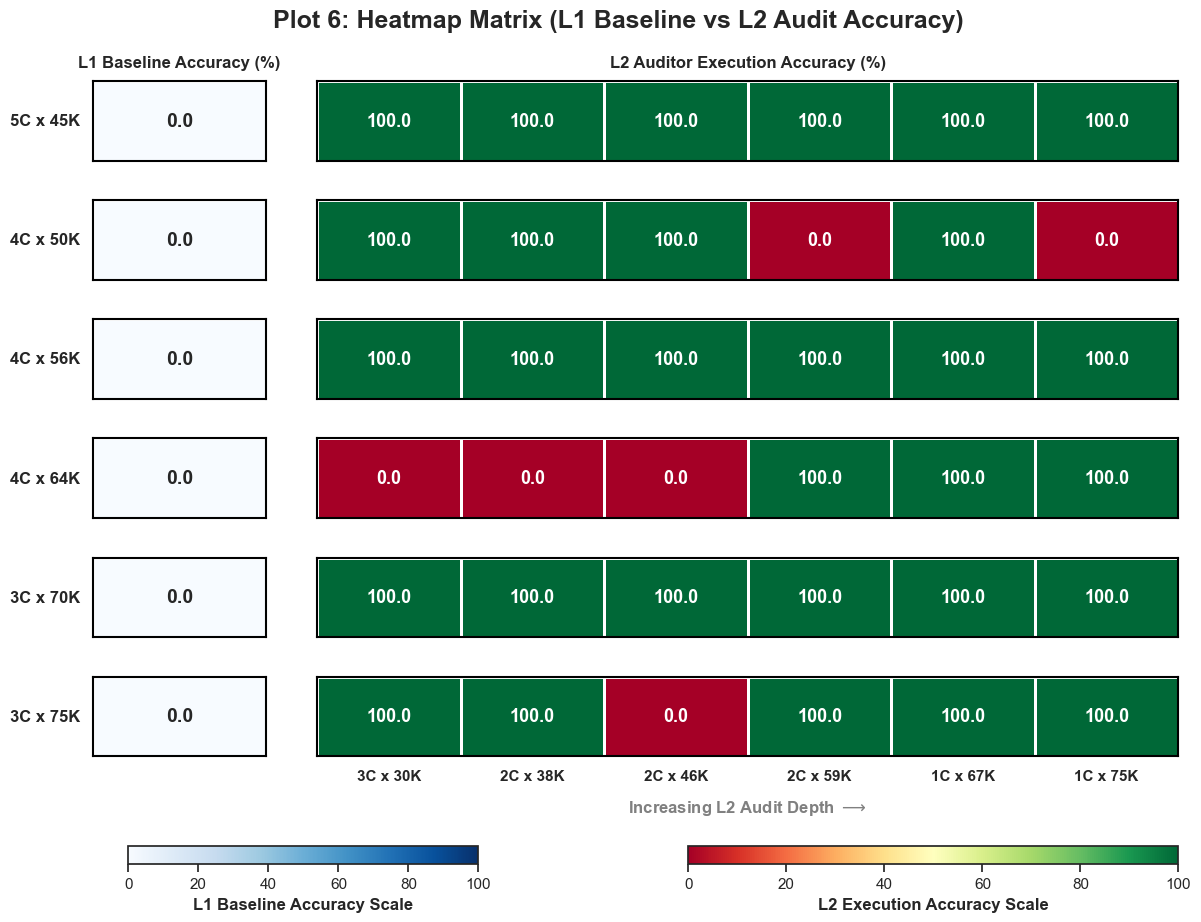

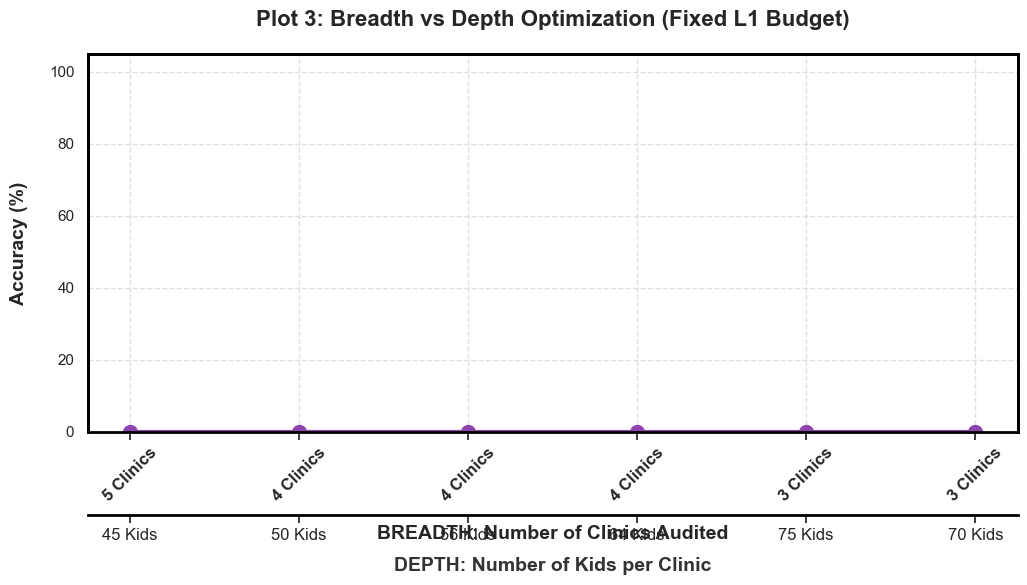

KeyError: "Label(s) ['V2_MAE_Acc'] do not exist"

In [14]:
# 6. DISPLAY THE RESULTS 
print("\n📊 Step 3: Rendering Plots...")
strategy_df = pd.read_csv(strategy_path)

# Plot 6: Heatmap Matrix (Filtering to 60% L1 Budget and 40% L2 Budget for the matrix slice)
fig6 = plotting_engine.plot_6_heatmap(
    strategy_df[(strategy_df['L1_Budget_Pct'] == '60%') & (strategy_df['L2_Budget_Pct'] == '40%')]
)
plt.show()

# Plot 3: Breadth vs Depth (Filtering to fixed 60% L1 Budget)
fig3 = plotting_engine.plot_3_breadth_depth(
    strategy_df[strategy_df['L1_Budget_Pct'] == '60%']
)
plt.show()

# Plot 2: Intra-Regional Accuracy
fig2 = plotting_engine.plot_2_intra_regional(strategy_df)
plt.show()

print(f"✅ Round Complete! Check {run_output_dir} for your saved Parquet and CSV files.")

may 25 data 2x2 good bad big data gen code

In [20]:
import sys
import os
import datetime
import pandas as pd
import importlib

# ==============================================================================
# 1. DIRECTORY SETUP
# ==============================================================================
services_path = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\api\services"
base_output_dir = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs"
if services_path not in sys.path: sys.path.append(services_path)

import data_generator
importlib.reload(data_generator)

preset_output_dir = os.path.join(base_output_dir, "Precalculated_Presets")
if not os.path.exists(preset_output_dir): os.makedirs(preset_output_dir)

MASTER_REGISTRY_PATH = os.path.join(base_output_dir, "simulation_master_registry.csv")

def log_universe_generation(params_dict, unique_task_id, preset_name, universe_file):
    """Appends a BRAND NEW row every single time. Never overwrites."""
    new_row = {
        "Task_ID": unique_task_id,           # Uniquely stamped (e.g., Good_L0_Good_L1_20260526_061007)
        "Base_Scenario": preset_name,        # Clean name for easy filtering
        "Timestamp_Step1_Gen": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "Universe_Data_File": universe_file,
        "Timestamp_Step2_Calc": "Pending", "n_simulations_used": "Pending", 
        "L1_Scorecard_File": "Pending", "L0_Scorecard_File": "Pending",
        "Timestamp_Step3_Eval": "Pending", "Final_Results_File": "Pending"
    }
    new_row.update(params_dict) 
    
    df_new = pd.DataFrame([new_row])
    if os.path.exists(MASTER_REGISTRY_PATH):
        df_existing = pd.read_csv(MASTER_REGISTRY_PATH)
        df_combined = pd.concat([df_existing, df_new], ignore_index=True)
        df_combined.to_csv(MASTER_REGISTRY_PATH, index=False)
    else:
        df_new.to_csv(MASTER_REGISTRY_PATH, index=False)


# ==============================================================================
# 2. CONFIGURATION ZONE (Easily Editable)
# ==============================================================================
base_params = {
    "n_L1s": 100, 
    "n_L0s_per_L1": 25, 
    "n_children_per_L0": 15,    
    "real_percent_stunting": 35.0, 
    "real_percent_underweight": 33.0, 
    "rho": 0.7,
    "sd_across_units_percent_under_reporting_stunting": 2.0,
    "sd_across_units_percent_under_reporting_underweight": 2.0,
    "sd_within_units_percent_under_reporting_stunting": 1.0,
    "sd_within_units_percent_under_reporting_underweight": 1.0,
    "sd_across_units_bunch_factor_haz": 0.01,
    "sd_across_units_bunch_factor_waz": 0.01,
    "sd_across_units_bunch_factor_whz": 0.01,
    "sd_within_units_bunch_factor_haz": 0.01,
    "sd_within_units_bunch_factor_waz": 0.01,
    "sd_within_units_bunch_factor_whz": 0.01,
    "sd_percent_copy": 2.0,
    "sd_collusion_index": 0.02,
    "mean_time_lag_L1": 15,
    "mean_time_lag_L2": 30
}

preset_scenarios = {
    "Good_L0_Good_L1": {
        "mean_percent_under_reporting_stunting": 5.0, 
        "mean_percent_under_reporting_underweight": 5.0,
        "mean_percent_under_reporting_wasting": 5.0,      
        "mean_bunch_factor_haz": 0.05, 
        "mean_bunch_factor_waz": 0.05, 
        "mean_bunch_factor_whz": 0.05,                    
        "mean_percent_copy": 5.0, 
        "mean_collusion_index": 0.05, 
        "error_sd_height_all_L0s": 0.0, 
        "error_sd_weight_all_L0s": 0.0
    },
    "Good_L0_Bad_L1": {
        "mean_percent_under_reporting_stunting": 5.0, 
        "mean_percent_under_reporting_underweight": 5.0,
        "mean_percent_under_reporting_wasting": 5.0,
        "mean_bunch_factor_haz": 0.05, 
        "mean_bunch_factor_waz": 0.05, 
        "mean_bunch_factor_whz": 0.05,
        "mean_percent_copy": 75.0, 
        "mean_collusion_index": 0.30, 
        "error_sd_height_all_L0s": 0.0, 
        "error_sd_weight_all_L0s": 0.0
    },
    "Bad_L0_Good_L1": {
        "mean_percent_under_reporting_stunting": 30.0, 
        "mean_percent_under_reporting_underweight": 30.0,
        "mean_percent_under_reporting_wasting": 30.0,
        "mean_bunch_factor_haz": 0.50, 
        "mean_bunch_factor_waz": 0.50, 
        "mean_bunch_factor_whz": 0.50,
        "mean_percent_copy": 5.0, 
        "mean_collusion_index": 0.05, 
        "error_sd_height_all_L0s": 0.0, 
        "error_sd_weight_all_L0s": 0.0
    },
    "Bad_L0_Bad_L1": {
        "mean_percent_under_reporting_stunting": 30.0, 
        "mean_percent_under_reporting_underweight": 30.0,
        "mean_percent_under_reporting_wasting": 30.0,
        "mean_bunch_factor_haz": 0.50, 
        "mean_bunch_factor_waz": 0.50, 
        "mean_bunch_factor_whz": 0.50,
        "mean_percent_copy": 40.0, 
        "mean_collusion_index": 0.50, 
        "error_sd_height_all_L0s": 0.0, 
        "error_sd_weight_all_L0s": 0.0
    }
}

# ==============================================================================
# 3. GENERATION LOOP (Only ONE loop, right here at the bottom)
# ==============================================================================
print("🚀 STEP 1: GENERATING UNIVERSES")
for preset_name, distortion_params in preset_scenarios.items():
    
    current_params = {**base_params, **distortion_params}
    
    # Generate timestamp and unique Task ID
    run_timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    unique_task_id = f"{preset_name}_{run_timestamp}"
    
    try:
        child_path, df_pop = data_generator.build_universe(current_params, unique_task_id, preset_output_dir)
        log_universe_generation(current_params, unique_task_id, preset_name, child_path)
        print(f"✅ Generated & Logged: {unique_task_id}")
    except Exception as e:
        print(f"❌ Error on {preset_name}: {e}")

🚀 STEP 1: GENERATING UNIVERSES


Assigning Personalities: 100%|██████████| 100/100 [00:00<00:00, 7034.59it/s]


✅ Generated & Logged: Good_L0_Good_L1_20260526_063027


Assigning Personalities: 100%|██████████| 100/100 [00:00<00:00, 7068.26it/s]


✅ Generated & Logged: Good_L0_Bad_L1_20260526_063458


Assigning Personalities: 100%|██████████| 100/100 [00:00<00:00, 5186.93it/s]


✅ Generated & Logged: Bad_L0_Good_L1_20260526_063931


Assigning Personalities: 100%|██████████| 100/100 [00:00<00:00, 7010.14it/s]


✅ Generated & Logged: Bad_L0_Bad_L1_20260526_064358


In [23]:
import pandas as pd
import os

def verify_latest_universes():
    registry_path = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\simulation_master_registry.csv"
    
    print("Loading Master Registry...")
    try:
        registry = pd.read_csv(registry_path)
    except Exception as e:
        print(f"❌ Error loading registry: {e}")
        return
        
    # Grab the last 4 rows generated
    latest_runs = registry.tail(4)
    
    for index, row in latest_runs.iterrows():
        task_id = row['Task_ID']
        file_path = row['Universe_Data_File']
        
        print(f"\n==================================================")
        print(f"🔎 DIAGNOSTICS FOR: {task_id}")
        print(f"==================================================")
        
        if not os.path.exists(file_path):
            print(f"❌ File not found at: {file_path}")
            continue
            
        try:
            df = pd.read_parquet(file_path, engine='pyarrow')
            
            # 1. Check for the missing raw columns
            has_raw = 'real_height' in df.columns
            print(f"1. Raw Physical Columns Restored? {'✅ YES' if has_raw else '❌ NO'}")
            
            # 2. Check the Stunting drop-off (The true test of the engine!)
            real_stunting = (df['real_haz'] < -2.0).mean() * 100
            l0_stunting = (df['L0_haz'] < -2.0).mean() * 100
            
            print(f"\n2. STUNTING RATES:")
            print(f"   God Mode (Real) Stunting: {real_stunting:.2f}%")
            print(f"   L0 Reported Stunting:     {l0_stunting:.2f}%")
            
            if (real_stunting - l0_stunting) > 5.0:
                print("   -> ✅ Massive drop detected! Fraud engine is actively hiding stunted kids.")
            else:
                print("   -> ⚠️ Minor/No drop detected. (Expected if this is a Good_L0 run).")
            
            # 3. True Manipulation Rates (Threshold > 0.05)
            haz_fraud = (df['L0_haz'] - df['real_haz']) > 0.05
            waz_fraud = (df['L0_waz'] - df['real_waz']) > 0.05
            
            haz_fraud_pct = haz_fraud.mean() * 100
            waz_fraud_pct = waz_fraud.mean() * 100
            
            print(f"\n3. TRUE MANIPULATION (Threshold > 0.05):")
            print(f"   Height (HAZ) maliciously faked: {haz_fraud.sum()} kids ({haz_fraud_pct:.2f}%)")
            print(f"   Weight (WAZ) maliciously faked: {waz_fraud.sum()} kids ({waz_fraud_pct:.2f}%)")
            
        except Exception as e:
            print(f"❌ Error testing {task_id}: {e}")

if __name__ == "__main__":
    verify_latest_universes()

Loading Master Registry...

🔎 DIAGNOSTICS FOR: Good_L0_Good_L1_20260526_063027
1. Raw Physical Columns Restored? ✅ YES

2. STUNTING RATES:
   God Mode (Real) Stunting: 34.86%
   L0 Reported Stunting:     34.83%
   -> ⚠️ Minor/No drop detected. (Expected if this is a Good_L0 run).

3. TRUE MANIPULATION (Threshold > 0.05):
   Height (HAZ) maliciously faked: 11 kids (0.03%)
   Weight (WAZ) maliciously faked: 20 kids (0.05%)

🔎 DIAGNOSTICS FOR: Good_L0_Bad_L1_20260526_063458
1. Raw Physical Columns Restored? ✅ YES

2. STUNTING RATES:
   God Mode (Real) Stunting: 35.05%
   L0 Reported Stunting:     35.01%
   -> ⚠️ Minor/No drop detected. (Expected if this is a Good_L0 run).

3. TRUE MANIPULATION (Threshold > 0.05):
   Height (HAZ) maliciously faked: 14 kids (0.04%)
   Weight (WAZ) maliciously faked: 13 kids (0.03%)

🔎 DIAGNOSTICS FOR: Bad_L0_Good_L1_20260526_063931
1. Raw Physical Columns Restored? ✅ YES

2. STUNTING RATES:
   God Mode (Real) Stunting: 35.19%
   L0 Reported Stunting:     23

next code to run step 2 calc

In [24]:
import sys
import os
import datetime
import pandas as pd
import importlib

# ==============================================================================
# 1. DIRECTORY SETUP
# ==============================================================================
utils_path = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\dashboard\src\utils\intervention_design"
base_output_dir = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs"
if utils_path not in sys.path: sys.path.append(utils_path)

import metrics_calculator
importlib.reload(metrics_calculator)

preset_output_dir = os.path.join(base_output_dir, "Precalculated_Presets")
MASTER_REGISTRY_PATH = os.path.join(base_output_dir, "simulation_master_registry.csv")

# ==============================================================================
# 2. AUDIT PARAMS & MANUAL TARGETS
# ==============================================================================
N_SIMULATIONS = 1  

# 👉 Paste the exact Task_IDs from Step 1 that you want to calculate here:
TARGET_BASE_UNIVERSES = [
    # "Good_L0_Good_L1_20260526_062039",
    "Good_L0_Good_L1_20260526_063027",
    "Good_L0_Bad_L1_20260526_063458",
    "Bad_L0_Good_L1_20260526_063931",
    "Bad_L0_Bad_L1_20260526_064358"
    

    # "Good_L0_Bad_L1_20260526_062048", # You can comment them out to skip them
]

# ==============================================================================
# 3. CALCULATE ENGINE (APPENDS NEW ROWS)
# ==============================================================================
print("⚙️ STEP 2: CALCULATING RAW SCORECARDS (MANUAL TARGET MODE)")
try:
    registry_df = pd.read_csv(MASTER_REGISTRY_PATH)
except FileNotFoundError:
    print(f"❌ Cannot find Registry at {MASTER_REGISTRY_PATH}. Run Step 1 first!")
    sys.exit()

# Filter the registry to ONLY include the tasks you manually typed above
base_universes = registry_df[registry_df['Task_ID'].isin(TARGET_BASE_UNIVERSES)]

if base_universes.empty:
    print("⚠️ No matching Task_IDs found in the registry. Did you copy the names correctly?")
    sys.exit()

for index, row in base_universes.iterrows():
    base_task_id = row['Task_ID']
    universe_path = row['Universe_Data_File']
    
    # Check if THIS universe has already been run with THIS n_simulations
    already_run = registry_df[
        (registry_df['Universe_Data_File'] == universe_path) & 
        (registry_df['n_simulations_used'] == str(N_SIMULATIONS))
    ]
    
    if not already_run.empty:
        print(f"⏩ Skipping {base_task_id}: Already calculated for N_SIMULATIONS = {N_SIMULATIONS}")
        continue

    print(f"\n=======================================================")
    print(f"⚙️ Crunching {N_SIMULATIONS} iterations for Blueprint: {base_task_id}...")
    print(f"=======================================================")
    
    if not pd.isna(universe_path) and not os.path.exists(str(universe_path)):
        print(f"⚠️ Could not find Universe file at {universe_path}. Skipping...")
        continue
        
    try:
        if str(universe_path).endswith('.parquet'): 
            df_pop = pd.read_parquet(universe_path, engine='pyarrow')
        else: 
            df_pop = pd.read_csv(universe_path)
            
        print(f"✅ Universe Loaded. Running Engine...")
        
        # Append a tag to the task_id so it creates a unique Step 2 ID
        calc_task_id = f"{base_task_id}_Calc_{N_SIMULATIONS}sims"
        
        path_l1, path_l0 = metrics_calculator.run_tracer_engine(
            df_pop=df_pop, 
            task_id=calc_task_id, 
            output_dir=preset_output_dir, 
            n_simulations=N_SIMULATIONS
        )
        
        # DUPLICATE THE ROW AND APPEND IT
        new_row = row.copy() 
        new_row['Task_ID'] = calc_task_id
        new_row['n_simulations_used'] = str(N_SIMULATIONS)
        new_row['L1_Scorecard_File'] = str(path_l1)
        new_row['L0_Scorecard_File'] = str(path_l0)
        new_row['Timestamp_Step2_Calc'] = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        new_row['Final_Results_File'] = "Pending" # Reset this for Step 3
        new_row['Timestamp_Step3_Eval'] = "Pending"
        
        # Append the new row to the dataframe and save it
        registry_df = pd.concat([registry_df, pd.DataFrame([new_row])], ignore_index=True)
        registry_df.to_csv(MASTER_REGISTRY_PATH, index=False)
        print(f"✅ New Row Appended to Registry for {calc_task_id}")
        
    except Exception as e:
        print(f"❌ Error on {base_task_id}: {e}")

print("\n🎉 STEP 2 COMPLETE! Master Registry has been updated with new rows.")

⚙️ STEP 2: CALCULATING RAW SCORECARDS (MANUAL TARGET MODE)

⚙️ Crunching 1 iterations for Blueprint: Good_L0_Good_L1_20260526_063027...
✅ Universe Loaded. Running Engine...
✅ New Row Appended to Registry for Good_L0_Good_L1_20260526_063027_Calc_1sims

⚙️ Crunching 1 iterations for Blueprint: Good_L0_Bad_L1_20260526_063458...
✅ Universe Loaded. Running Engine...
✅ New Row Appended to Registry for Good_L0_Bad_L1_20260526_063458_Calc_1sims

⚙️ Crunching 1 iterations for Blueprint: Bad_L0_Good_L1_20260526_063931...
✅ Universe Loaded. Running Engine...
✅ New Row Appended to Registry for Bad_L0_Good_L1_20260526_063931_Calc_1sims

⚙️ Crunching 1 iterations for Blueprint: Bad_L0_Bad_L1_20260526_064358...
✅ Universe Loaded. Running Engine...
✅ New Row Appended to Registry for Bad_L0_Bad_L1_20260526_064358_Calc_1sims

🎉 STEP 2 COMPLETE! Master Registry has been updated with new rows.


In [25]:
import pandas as pd
import os

def validate_step2_scorecards():
    registry_path = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\simulation_master_registry.csv"
    
    print("Loading Master Registry...")
    registry = pd.read_csv(registry_path)
    
    # Grab the 4 Golden Runs
    latest_runs = registry.tail(4)
    
    for index, row in latest_runs.iterrows():
        task_id = row['Task_ID']
        l1_scorecard_path = row['L1_Scorecard_File']
        
        print(f"\n==================================================")
        print(f"📊 CHECKING SCORECARD: {task_id}")
        print(f"==================================================")
        
        if pd.isna(l1_scorecard_path) or str(l1_scorecard_path).strip() == "Pending":
            print("❌ Scorecard missing from registry!")
            continue
            
        if not os.path.exists(l1_scorecard_path):
            print(f"❌ File not found at path: {l1_scorecard_path}")
            continue
            
        try:
            # =========================================================
            # THE FIX: Smart file reader based on the extension!
            # =========================================================
            if str(l1_scorecard_path).endswith('.parquet'):
                df_scorecard = pd.read_parquet(l1_scorecard_path, engine='pyarrow')
            else:
                df_scorecard = pd.read_csv(l1_scorecard_path)
                
            print(f"✅ Scorecard Loaded! (Rows: {len(df_scorecard)}, Columns: {len(df_scorecard.columns)})")
            
            # Look for Metric Columns (MAE, Error, Flags, etc.)
            metric_cols = [col for col in df_scorecard.columns if 'mae' in col.lower() or 'error' in col.lower() or 'diff' in col.lower()]
            
            if metric_cols:
                print(f"✅ Calculation Success! Found metric columns:")
                # Print the first 4 metric columns to verify they have data
                for col in metric_cols[:4]:
                    mean_val = df_scorecard[col].mean()
                    print(f"   -> {col} (Average: {mean_val:.4f})")
            else:
                print(f"⚠️ Warning: Opened the file but couldn't find expected metric columns.")
                print(f"   Actual columns found: {list(df_scorecard.columns)[:5]}...")
                
        except Exception as e:
            print(f"❌ Error reading scorecard: {e}")

if __name__ == '__main__':
    validate_step2_scorecards()

Loading Master Registry...

📊 CHECKING SCORECARD: Good_L0_Good_L1_20260526_063027_Calc_1sims
✅ Scorecard Loaded! (Rows: 80000, Columns: 10)
✅ Calculation Success! Found metric columns:
   -> True_L1_MAE (Average: 0.0006)
   -> Meas_L1_MAE (Average: 0.0026)
   -> Meas_L2_MAE (Average: 0.0019)

📊 CHECKING SCORECARD: Good_L0_Bad_L1_20260526_063458_Calc_1sims
✅ Scorecard Loaded! (Rows: 80000, Columns: 10)
✅ Calculation Success! Found metric columns:
   -> True_L1_MAE (Average: 0.0005)
   -> Meas_L1_MAE (Average: 0.1046)
   -> Meas_L2_MAE (Average: 0.1045)

📊 CHECKING SCORECARD: Bad_L0_Good_L1_20260526_063931_Calc_1sims
✅ Scorecard Loaded! (Rows: 80000, Columns: 10)
✅ Calculation Success! Found metric columns:
   -> True_L1_MAE (Average: 0.0979)
   -> Meas_L1_MAE (Average: 0.0988)
   -> Meas_L2_MAE (Average: 0.0028)

📊 CHECKING SCORECARD: Bad_L0_Bad_L1_20260526_064358_Calc_1sims
✅ Scorecard Loaded! (Rows: 80000, Columns: 10)
✅ Calculation Success! Found metric columns:
   -> True_L1_MAE (Av

part 3 target end filters outputs 

In [26]:
import sys
import os
import datetime
import pandas as pd

# ==============================================================================
# 1. DIRECTORY SETUP
# ==============================================================================
base_output_dir = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs"
preset_output_dir = os.path.join(base_output_dir, "Precalculated_Presets")
MASTER_REGISTRY_PATH = os.path.join(base_output_dir, "simulation_master_registry.csv")

# ==============================================================================
# 2. MANUAL TARGETS
# ==============================================================================
# 👉 Paste the exact Step 2 Task_IDs (the ones with _Calc_Xsims) here:
TARGET_CALCULATED_RUNS = [
    "Good_L0_Good_L1_20260526_063027_Calc_1sims",
    "Good_L0_Bad_L1_20260526_063458_Calc_1sims",
    "Bad_L0_Good_L1_20260526_063931_Calc_1sims",
    "Bad_L0_Bad_L1_20260526_064358_Calc_1sims"
    
]

# ==============================================================================
# 3. EVALUATION ENGINE
# ==============================================================================
print("🚀 STEP 3: EVALUATING FINAL RESULTS (MANUAL TARGET MODE)")
try:
    registry_df = pd.read_csv(MASTER_REGISTRY_PATH)
except FileNotFoundError:
    print(f"❌ Cannot find Registry at {MASTER_REGISTRY_PATH}. Run Step 1 first!")
    sys.exit()

# Filter the registry to ONLY include the tasks you manually typed above
target_runs = registry_df[registry_df['Task_ID'].isin(TARGET_CALCULATED_RUNS)]

if target_runs.empty:
    print("⚠️ No matching Task_IDs found in the registry. Did you copy the names correctly?")
    sys.exit()

for index, row in target_runs.iterrows():
    task_id = row['Task_ID']
    l1_scorecard_path = row['L1_Scorecard_File']
    
    # Ensure Step 2 actually finished for this row
    if pd.isna(l1_scorecard_path) or str(l1_scorecard_path).strip() == "Pending":
        print(f"⏩ Skipping {task_id}: Step 2 (Scorecards) not calculated yet.")
        continue
        
    # Ensure Step 3 isn't already done
    final_status = row.get('Final_Results_File')
    if pd.notna(final_status) and str(final_status).strip() != "Pending":
        print(f"⏩ Skipping {task_id}: Final Evaluation already exists.")
        continue

    print(f"\n=======================================================")
    print(f"📊 Evaluating Monte Carlo Aggregates for: {task_id}...")
    print(f"=======================================================")
    
    if not os.path.exists(str(l1_scorecard_path)):
        print(f"⚠️ Could not find L1 Scorecard at {l1_scorecard_path}. Skipping...")
        continue
        
    try:
        # Smart file reader for the scorecard
        if str(l1_scorecard_path).endswith('.parquet'):
            df_l1 = pd.read_parquet(l1_scorecard_path, engine='pyarrow')
        else:
            df_l1 = pd.read_csv(l1_scorecard_path)
            
        print(f"✅ Scorecard Loaded. Aggregating {df_l1['Sim_ID'].nunique()} simulations...")
        
        # Aggregate the simulations into clean averages
        eval_df = df_l1.groupby(['Indicator', 'L1_Budget_Pct', 'L2_Budget_Pct', 'L1_Label', 'L2_Label']).agg(
            Avg_True_L1_MAE=('True_L1_MAE', 'mean'),
            Avg_Meas_L1_MAE=('Meas_L1_MAE', 'mean'),
            Avg_Meas_L2_MAE=('Meas_L2_MAE', 'mean'),
            Total_Simulations=('Sim_ID', 'count')
        ).reset_index()
        
        # Save the Final Evaluated File
        final_output_path = os.path.join(preset_output_dir, f"final_evaluation_{task_id}.csv")
        eval_df.to_csv(final_output_path, index=False)
        
        # Update the CURRENT ROW in the master registry (No appending needed)
        registry_df.loc[registry_df['Task_ID'] == task_id, 'Final_Results_File'] = str(final_output_path)
        registry_df.loc[registry_df['Task_ID'] == task_id, 'Timestamp_Step3_Eval'] = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        
        registry_df.to_csv(MASTER_REGISTRY_PATH, index=False)
        print(f"✅ Evaluation Complete & Registry Updated for {task_id}")
        
    except Exception as e:
        print(f"❌ Error evaluating {task_id}: {e}")

print("\n🏁 STEP 3 COMPLETE! The Master Registry has been updated.")

🚀 STEP 3: EVALUATING FINAL RESULTS (MANUAL TARGET MODE)

📊 Evaluating Monte Carlo Aggregates for: Good_L0_Good_L1_20260526_063027_Calc_1sims...
✅ Scorecard Loaded. Aggregating 1 simulations...
✅ Evaluation Complete & Registry Updated for Good_L0_Good_L1_20260526_063027_Calc_1sims

📊 Evaluating Monte Carlo Aggregates for: Good_L0_Bad_L1_20260526_063458_Calc_1sims...
✅ Scorecard Loaded. Aggregating 1 simulations...
✅ Evaluation Complete & Registry Updated for Good_L0_Bad_L1_20260526_063458_Calc_1sims

📊 Evaluating Monte Carlo Aggregates for: Bad_L0_Good_L1_20260526_063931_Calc_1sims...
✅ Scorecard Loaded. Aggregating 1 simulations...
✅ Evaluation Complete & Registry Updated for Bad_L0_Good_L1_20260526_063931_Calc_1sims

📊 Evaluating Monte Carlo Aggregates for: Bad_L0_Bad_L1_20260526_064358_Calc_1sims...
✅ Scorecard Loaded. Aggregating 1 simulations...
✅ Evaluation Complete & Registry Updated for Bad_L0_Bad_L1_20260526_064358_Calc_1sims

🏁 STEP 3 COMPLETE! The Master Registry has been upd

In [28]:
import pandas as pd
import os

def inspect_step3_outputs():
    base_output_dir = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs"
    preset_output_dir = os.path.join(base_output_dir, "Precalculated_Presets")
    
    # The 4 exact runs Step 3 just finished evaluating
    target_runs = [
        "Good_L0_Good_L1_20260526_063027_Calc_1sims",
        "Good_L0_Bad_L1_20260526_063458_Calc_1sims",
        "Bad_L0_Good_L1_20260526_063931_Calc_1sims",
        "Bad_L0_Bad_L1_20260526_064358_Calc_1sims"
    ]
    
    print("👀 PEEKING INSIDE STEP 3 EVALUATED SCENARIOS:\n")
    
    for run in target_runs:
        file_path = os.path.join(preset_output_dir, f"final_evaluation_{run}.csv")
        
        print(f"================================================================")
        print(f"📊 FILE: final_evaluation_{run}.csv")
        print(f"================================================================")
        
        if not os.path.exists(file_path):
            print(f"❌ Could not find file at: {file_path}")
            continue
            
        # Load the final evaluation table
        df = pd.read_csv(file_path)
        print(f"✅ Shape: {df.shape[0]} rows (budget matrix slices) x {df.shape[1]} columns")
        
        # Display the first few rows to see the matrix structure
        print("\n📈 Sample Data Slices:")
        print(df[['Indicator', 'L1_Budget_Pct', 'L2_Budget_Pct', 'Avg_True_L1_MAE', 'Avg_Meas_L1_MAE', 'Avg_Meas_L2_MAE']].head(3))
        print("\n")

if __name__ == "__main__":
    inspect_step3_outputs()

👀 PEEKING INSIDE STEP 3 EVALUATED SCENARIOS:

📊 FILE: final_evaluation_Good_L0_Good_L1_20260526_063027_Calc_1sims.csv
✅ Shape: 714 rows (budget matrix slices) x 9 columns

📈 Sample Data Slices:
  Indicator L1_Budget_Pct L2_Budget_Pct  Avg_True_L1_MAE  Avg_Meas_L1_MAE  \
0    Height           10%           10%         0.000455         0.001986   
1    Height           10%           10%         0.000455         0.001986   
2    Height           10%           10%         0.000455         0.003377   

   Avg_Meas_L2_MAE  
0         0.001572  
1         0.001441  
2         0.001834  


📊 FILE: final_evaluation_Good_L0_Bad_L1_20260526_063458_Calc_1sims.csv
✅ Shape: 714 rows (budget matrix slices) x 9 columns

📈 Sample Data Slices:
  Indicator L1_Budget_Pct L2_Budget_Pct  Avg_True_L1_MAE  Avg_Meas_L1_MAE  \
0    Height           10%           10%         0.000566         0.130785   
1    Height           10%           10%         0.000566         0.130785   
2    Height           10%        

In [ ]:
#1
import sys
import os
import datetime
import pandas as pd
import numpy as np

# ==============================================================================
# 1. DIRECTORY SETUP
# ==============================================================================
base_output_dir = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs"
preset_output_dir = os.path.join(base_output_dir, "Precalculated_Presets")
MASTER_REGISTRY_PATH = os.path.join(base_output_dir, "simulation_master_registry.csv")

# ==============================================================================
# 2. MANUAL TARGETS & CONFIGURATION
# ==============================================================================
TARGET_CALCULATED_RUNS = [
    "Good_L0_Good_L1_20260526_063027_Calc_1sims",
    "Good_L0_Bad_L1_20260526_063458_Calc_1sims",
    "Bad_L0_Good_L1_20260526_063931_Calc_1sims",
    "Bad_L0_Bad_L1_20260526_064358_Calc_1sims"
]

TARGET_PERCENTILE = 0.30  # Matches your default 30% dashboard slider

# ==============================================================================
# 3. RANKING ACCURACY CORE ALGORITHM
# ==============================================================================
def calculate_simulation_accuracy(group, target_pct=0.30):
    """Calculates the exact detection sensitivity for a single simulation run."""
    n_units = len(group)
    k = max(1, int(round(n_units * target_pct)))
    
    # 1. Identify the absolute true worst offenders (highest True MAE)
    true_worst = set(group.nlargest(k, 'True_L1_MAE')['L1_id'].values)
    
    # 2. Identify who the L1 supervisor and L2 auditor thought were the worst
    meas_l1_worst = set(group.nlargest(k, 'Meas_L1_MAE')['L1_id'].values)
    meas_l2_worst = set(group.nlargest(k, 'Meas_L2_MAE')['L1_id'].values)
    
    # 3. Compute detection percentage (Intersection over Target Size)
    v1_acc = (len(true_worst & meas_l1_worst) / k) * 100.0
    v3_acc = (len(true_worst & meas_l2_worst) / k) * 100.0
    
    return pd.Series({
        'V1_MAE_Acc': v1_acc,
        'V2_MAE_Acc': v1_acc,  # Map L1 accuracy to V2 for Plot 2 usage
        'V3_MAE_Acc': v3_acc   # Map L2 accuracy to V3 for Plot 6 Heatmap
    })

# ==============================================================================
# 4. EXECUTION RUNNER
# ==============================================================================
print("🚀 STEP 3: EVALUATING FINAL RANKING ACCURACIES")
try:
    registry_df = pd.read_csv(MASTER_REGISTRY_PATH)
except FileNotFoundError:
    print(f"❌ Cannot find Registry at {MASTER_REGISTRY_PATH}.")
    sys.exit()

target_runs = registry_df[registry_df['Task_ID'].isin(TARGET_CALCULATED_RUNS)]

if target_runs.empty:
    print("⚠️ No matching Task_IDs found in the registry.")
    sys.exit()

for index, row in target_runs.iterrows():
    task_id = row['Task_ID']
    l1_scorecard_path = row['L1_Scorecard_File']
    
    if pd.isna(l1_scorecard_path) or str(l1_scorecard_path).strip() == "Pending":
        print(f"⏩ Skipping {task_id}: Step 2 scorecard data missing.")
        continue
        
    print(f"\n=======================================================")
    print(f"📊 Calculating Detection power for: {task_id}...")
    print(f"=======================================================")
    
    if not os.path.exists(str(l1_scorecard_path)):
        print(f"⚠️ Could not find file at {l1_scorecard_path}. Skipping...")
        continue
        
    try:
        # Load Raw Step 2 Iterations
        df_l1 = pd.read_parquet(l1_scorecard_path, engine='pyarrow') if str(l1_scorecard_path).endswith('.parquet') else pd.read_csv(l1_scorecard_path)
        
        print(f"✅ Scorecard Loaded. Running ranking intersection across variables...")
        
        # --- PHASE 1: Calculate Accuracies for every individual Sim_ID iteration ---
        sim_acc_df = df_l1.groupby([
            'Indicator', 'L1_Budget_Pct', 'L1_Label', 'L2_Budget_Pct', 'L2_Label', 'Sim_ID'
        ]).apply(calculate_simulation_accuracy, target_pct=TARGET_PERCENTILE).reset_index()
        
        # --- PHASE 2: Aggregate across Monte Carlo runs to get mean and standard deviations ---
        final_eval = sim_acc_df.groupby([
            'Indicator', 'L1_Budget_Pct', 'L1_Label', 'L2_Budget_Pct', 'L2_Label'
        ]).agg(
            V1_MAE_Acc=('V1_MAE_Acc', 'mean'),
            V1_MAE_Std=('V1_MAE_Acc', 'std'),
            V2_MAE_Acc=('V2_MAE_Acc', 'mean'),
            V2_MAE_Std=('V2_MAE_Acc', 'std'),
            V3_MAE_Acc=('V3_MAE_Acc', 'mean'),
            V3_MAE_Std=('V3_MAE_Acc', 'std')
        ).reset_index()
        
        # Fallback for 1-simulation runs where std dev defaults to NaN
        final_eval.fillna(0.0, inplace=True)
        
        # --- PHASE 3: Extract numeric integers from text labels for Plotting Engine ---
        final_eval['L1_C'] = final_eval['L1_Label'].apply(lambda x: int(x.split('C')[0]))
        final_eval['L1_K'] = final_eval['L1_Label'].apply(lambda x: int(x.split('x')[1].split('K')[0].strip()))
        final_eval['L2_C'] = final_eval['L2_Label'].apply(lambda x: int(x.split('C')[0]))
        final_eval['L2_K'] = final_eval['L2_Label'].apply(lambda x: int(x.split('x')[1].split('K')[0].strip()))
        
        # Save output to disk
        final_output_path = os.path.join(preset_output_dir, f"final_evaluation_{task_id}.csv")
        final_eval.to_csv(final_output_path, index=False)
        
        # Update Master Registry row
        registry_df.loc[registry_df['Task_ID'] == task_id, 'Final_Results_File'] = str(final_output_path)
        registry_df.loc[registry_df['Task_ID'] == task_id, 'Timestamp_Step3_Eval'] = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        registry_df.to_csv(MASTER_REGISTRY_PATH, index=False)
        
        print(f"✅ Upgraded Step 3 Data generated for {task_id}")
        
    except Exception as e:
        print(f"❌ Error evaluating {task_id}: {e}")

print("\n🏁 STEP 3 UPGRADE COMPLETE! Your data files perfectly match your plotting requirements.")

🚀 STEP 3: EVALUATING FINAL RANKING ACCURACIES

📊 Calculating Detection power for: Good_L0_Good_L1_20260526_063027_Calc_1sims...
✅ Scorecard Loaded. Running ranking intersection across variables...
✅ Upgraded Step 3 Data generated for Good_L0_Good_L1_20260526_063027_Calc_1sims

📊 Calculating Detection power for: Good_L0_Bad_L1_20260526_063458_Calc_1sims...
✅ Scorecard Loaded. Running ranking intersection across variables...
✅ Upgraded Step 3 Data generated for Good_L0_Bad_L1_20260526_063458_Calc_1sims

📊 Calculating Detection power for: Bad_L0_Good_L1_20260526_063931_Calc_1sims...
✅ Scorecard Loaded. Running ranking intersection across variables...
✅ Upgraded Step 3 Data generated for Bad_L0_Good_L1_20260526_063931_Calc_1sims

📊 Calculating Detection power for: Bad_L0_Bad_L1_20260526_064358_Calc_1sims...
✅ Scorecard Loaded. Running ranking intersection across variables...
✅ Upgraded Step 3 Data generated for Bad_L0_Bad_L1_20260526_064358_Calc_1sims

🏁 STEP 3 UPGRADE COMPLETE! Your data 

: 

In [9]:
1+1

2

may 27 validation

step 1

In [17]:
import sys
import os
import datetime
import pandas as pd
import importlib

# ==============================================================================
# 1. DIRECTORY SETUP
# ==============================================================================
services_path = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\api\services"
base_output_dir = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs"

if services_path not in sys.path: 
    sys.path.append(services_path)

import data_generator
importlib.reload(data_generator)

preset_output_dir = os.path.join(base_output_dir, "Precalculated_Presets")
if not os.path.exists(preset_output_dir): 
    os.makedirs(preset_output_dir)

MASTER_REGISTRY_PATH = os.path.join(base_output_dir, "simulation_master_registry.csv")

def log_universe_generation(params_dict, unique_task_id, preset_name, universe_file):
    """Appends a BRAND NEW row every single time. Never overwrites."""
    new_row = {
        "Task_ID": unique_task_id,
        "Base_Scenario": preset_name,
        "Timestamp_Step1_Gen": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "Universe_Data_File": universe_file,
        "Timestamp_Step2_Calc": "Pending", "n_simulations_used": "Pending", 
        "L1_Scorecard_File": "Pending", "L0_Scorecard_File": "Pending",
        "Timestamp_Step3_Eval": "Pending", "L1_Summary_File": "Pending", "L0_Summary_File": "Pending"
    }
    new_row.update(params_dict) 
    
    df_new = pd.DataFrame([new_row])
    if os.path.exists(MASTER_REGISTRY_PATH):
        df_existing = pd.read_csv(MASTER_REGISTRY_PATH)
        df_combined = pd.concat([df_existing, df_new], ignore_index=True)
        df_combined.to_csv(MASTER_REGISTRY_PATH, index=False)
    else:
        df_new.to_csv(MASTER_REGISTRY_PATH, index=False)

# ==============================================================================
# 2. CONFIGURATION ZONE (Easily Editable)
# ==============================================================================
base_params = {
    "n_L1s": 100, 
    "n_L0s_per_L1": 25, 
    "n_children_per_L0": 15,    
    "real_percent_stunting": 35.0, 
    "real_percent_underweight": 33.0, 
    "rho": 0.7,
    "sd_across_units_percent_under_reporting_stunting": 2.0,
    "sd_across_units_percent_under_reporting_underweight": 2.0,
    "sd_within_units_percent_under_reporting_stunting": 1.0,
    "sd_within_units_percent_under_reporting_underweight": 1.0,
    "sd_across_units_bunch_factor_haz": 0.01,
    "sd_across_units_bunch_factor_waz": 0.01,
    "sd_within_units_bunch_factor_haz": 0.01,
    "sd_within_units_bunch_factor_waz": 0.01,
    "sd_percent_copy": 2.0,
    "sd_collusion_index": 0.02,
    "mean_time_lag_L1": 15,
    "mean_time_lag_L2": 30
}

preset_scenarios = {
    "Good_L0_Good_L1": {
        "mean_percent_under_reporting_stunting": 5.0, 
        "mean_percent_under_reporting_underweight": 5.0,
        "mean_bunch_factor_haz": 0.05, 
        "mean_bunch_factor_waz": 0.05, 
        "mean_percent_copy": 5.0, 
        "mean_collusion_index": 0.05, 
        "error_sd_height_all_L0s": 0.0, 
        "error_sd_weight_all_L0s": 0.0
    },
    "Good_L0_Bad_L1": {
        "mean_percent_under_reporting_stunting": 5.0, 
        "mean_percent_under_reporting_underweight": 5.0,
        "mean_bunch_factor_haz": 0.05, 
        "mean_bunch_factor_waz": 0.05, 
        "mean_percent_copy": 75.0, 
        "mean_collusion_index": 0.30, 
        "error_sd_height_all_L0s": 0.0, 
        "error_sd_weight_all_L0s": 0.0
    },
    "Bad_L0_Good_L1": {
        "mean_percent_under_reporting_stunting": 30.0, 
        "mean_percent_under_reporting_underweight": 30.0,
        "mean_bunch_factor_haz": 0.50, 
        "mean_bunch_factor_waz": 0.50, 
        "mean_percent_copy": 5.0, 
        "mean_collusion_index": 0.05, 
        "error_sd_height_all_L0s": 0.0, 
        "error_sd_weight_all_L0s": 0.0
    },
    "Bad_L0_Bad_L1": {
        "mean_percent_under_reporting_stunting": 30.0, 
        "mean_percent_under_reporting_underweight": 30.0,
        "mean_bunch_factor_haz": 0.50, 
        "mean_bunch_factor_waz": 0.50, 
        "mean_percent_copy": 40.0, 
        "mean_collusion_index": 0.50, 
        "error_sd_height_all_L0s": 0.0, 
        "error_sd_weight_all_L0s": 0.0
    }
}

# ==============================================================================
# 3. GENERATION LOOP
# ==============================================================================
print("STEP 1: GENERATING UNIVERSES")
for preset_name, distortion_params in preset_scenarios.items():
    
    current_params = {**base_params, **distortion_params}
    
    run_timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    unique_task_id = f"{preset_name}_{run_timestamp}"
    
    try:
        child_path, df_pop = data_generator.build_universe(current_params, unique_task_id, preset_output_dir)
        log_universe_generation(current_params, unique_task_id, preset_name, child_path)
        print(f"Generated & Logged: {unique_task_id}")
    except Exception as e:
        print(f"Error on {preset_name}: {e}")

STEP 1: GENERATING UNIVERSES
   -> [Step 1] Building Synthetic Universe for task: Good_L0_Good_L1_20260528_145250
      * Simulating field fraud physics...


Assigning Personalities: 100%|██████████| 100/100 [00:00<00:00, 5672.58it/s]


Generated & Logged: Good_L0_Good_L1_20260528_145250
   -> [Step 1] Building Synthetic Universe for task: Good_L0_Bad_L1_20260528_150009
      * Simulating field fraud physics...


Assigning Personalities: 100%|██████████| 100/100 [00:00<00:00, 2060.48it/s]


Generated & Logged: Good_L0_Bad_L1_20260528_150009
   -> [Step 1] Building Synthetic Universe for task: Bad_L0_Good_L1_20260528_151136
      * Simulating field fraud physics...


Assigning Personalities: 100%|██████████| 100/100 [00:00<00:00, 2451.19it/s]


Generated & Logged: Bad_L0_Good_L1_20260528_151136
   -> [Step 1] Building Synthetic Universe for task: Bad_L0_Bad_L1_20260528_152028
      * Simulating field fraud physics...


Assigning Personalities: 100%|██████████| 100/100 [00:00<00:00, 4750.81it/s]


Generated & Logged: Bad_L0_Bad_L1_20260528_152028


step 2

In [18]:
import sys
import os
import datetime
import pandas as pd
import importlib
import warnings

warnings.filterwarnings("ignore")

# ==============================================================================
# 1. DIRECTORY SETUP
# ==============================================================================
services_path = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\api\services"
base_output_dir = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs"
if services_path not in sys.path: sys.path.append(services_path)

import metrics_calculator
importlib.reload(metrics_calculator)

preset_output_dir = os.path.join(base_output_dir, "Precalculated_Presets")
MASTER_REGISTRY_PATH = os.path.join(base_output_dir, "simulation_master_registry.csv")

# ==============================================================================
# 2. AUDIT PARAMS & MANUAL TARGETS
# ==============================================================================
N_SIMULATIONS = 1

TARGET_BASE_UNIVERSES = [
    "Good_L0_Good_L1_20260528_145250",
    "Good_L0_Bad_L1_20260528_150009",
    "Bad_L0_Good_L1_20260528_151136",
    "Bad_L0_Bad_L1_20260528_152028"
    # "Good_L0_Bad_L1_20260528_125732",
    # "Bad_L0_Good_L1_20260528_125812",
    # "Bad_L0_Bad_L1_20260528_125927"
]

# ==============================================================================
# 3. CALCULATE ENGINE (APPENDS NEW ROWS)
# ==============================================================================
print("STEP 2: CALCULATING RAW SCORECARDS (MANUAL TARGET MODE)")
try:
    registry_df = pd.read_csv(MASTER_REGISTRY_PATH)
except FileNotFoundError:
    print(f"Cannot find Registry at {MASTER_REGISTRY_PATH}. Run Step 1 first!")
    sys.exit()

base_universes = registry_df[registry_df['Task_ID'].isin(TARGET_BASE_UNIVERSES)]

if base_universes.empty:
    print("No matching Task_IDs found in the registry. Check copied names.")
    sys.exit()

for index, row in base_universes.iterrows():
    base_task_id = row['Task_ID']
    universe_path = row['Universe_Data_File']
    
    already_run = registry_df[
        (registry_df['Universe_Data_File'] == universe_path) & 
        (registry_df['n_simulations_used'] == str(N_SIMULATIONS))
    ]
    
    if not already_run.empty:
        print(f"Skipping {base_task_id}: Already calculated for N_SIMULATIONS = {N_SIMULATIONS}")
        continue

    print(f"\n=======================================================")
    print(f"Crunching {N_SIMULATIONS} iterations for Blueprint: {base_task_id}...")
    print(f"=======================================================")
    
    if pd.isna(universe_path) or not os.path.exists(str(universe_path)):
        print(f"Could not find Universe file at {universe_path}. Skipping...")
        continue
        
    try:
        # Load without forcing the pyarrow backend
        if str(universe_path).endswith('.parquet'): 
            df_pop = pd.read_parquet(universe_path)
        else: 
            df_pop = pd.read_csv(universe_path)
            
        # === THE BOTTLENECK FIX ===
        # Convert all string/text columns to Categories. 
        # This completely bypasses the PyArrow string conversion lag and speeds up groupby() operations by 100x.
        for col in df_pop.select_dtypes(include=['object', 'string']).columns:
            df_pop[col] = df_pop[col].astype('category')
            
        print(f"Universe Loaded & Optimized. Running Engine...")
        
        calc_task_id = f"{base_task_id}_Calc_{N_SIMULATIONS}sims"
        
        path_l0, path_l1 = metrics_calculator.run_tracer_engine(
            df_pop=df_pop, 
            task_id=calc_task_id, 
            output_dir=preset_output_dir, 
            n_simulations=N_SIMULATIONS,
            indicators=["Height", "Weight"]
        )
        
        new_row = row.copy() 
        new_row['Task_ID'] = calc_task_id
        new_row['n_simulations_used'] = str(N_SIMULATIONS)
        new_row['L1_Scorecard_File'] = str(path_l1)
        new_row['L0_Scorecard_File'] = str(path_l0)
        new_row['Timestamp_Step2_Calc'] = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        new_row['L1_Summary_File'] = "Pending" 
        new_row['L0_Summary_File'] = "Pending"
        new_row['Timestamp_Step3_Eval'] = "Pending"
        
        registry_df = pd.concat([registry_df, pd.DataFrame([new_row])], ignore_index=True)
        registry_df.to_csv(MASTER_REGISTRY_PATH, index=False)
        print(f"New Row Appended to Registry for {calc_task_id}")
        
    except Exception as e:
        print(f"Error on {base_task_id}: {e}")

print("\nSTEP 2 COMPLETE! Master Registry has been updated with new rows.")

STEP 2: CALCULATING RAW SCORECARDS (MANUAL TARGET MODE)

Crunching 1 iterations for Blueprint: Good_L0_Good_L1_20260528_145250...
Universe Loaded & Optimized. Running Engine...
   -> [Step 2] Executing Math Matrix Engine for Task: Good_L0_Good_L1_20260528_145250_Calc_1sims
      * Processing Indicator: Height...
      * Processing Indicator: Weight...
   -> [Step 2] Complete. Matrix Files Extracted to:
      1. C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\calculated_metrics_L0_Good_L0_Good_L1_20260528_145250_Calc_1sims.parquet
      2. C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\calculated_metrics_L1_Good_L0_Good_L1_20260528_145250_Calc_1sims.parquet
New Row Appended to Registry for Good_L0_Good_L1_20260528_145250_Calc_1sims

Crunching 1 iterations for Blueprint: Good_L0_Bad_L1_20260528_150009...
Universe Loaded & Optimized. Running Engine...
   -> [Step 2] Executing Math Matrix E

In [11]:
import pandas as pd
import os

# ==============================================================================
# 1. DEFINE FILE PATHS
# ==============================================================================
preset_dir = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets"

# L0 Files
l0_2sims_path = os.path.join(preset_dir, "calculated_metrics_L0_Good_L0_Good_L1_20260528_125658_Calc_2sims.parquet")
l0_3sims_path = os.path.join(preset_dir, "calculated_metrics_L0_Good_L0_Good_L1_20260528_125658_Calc_3sims.parquet")

# L1 Files
l1_2sims_path = os.path.join(preset_dir, "calculated_metrics_L1_Good_L0_Good_L1_20260528_125658_Calc_2sims.parquet")
l1_3sims_path = os.path.join(preset_dir, "calculated_metrics_L1_Good_L0_Good_L1_20260528_125658_Calc_3sims.parquet")

# ==============================================================================
# 2. COMPARISON FUNCTION
# ==============================================================================
def compare_parquets(file1, file2, label):
    print(f"\n{'='*60}")
    print(f" COMPARING {label.upper()} SCORECARDS")
    print(f"{'='*60}")
    
    if not os.path.exists(file1) or not os.path.exists(file2):
        print("ERROR: One or both files do not exist. Check paths.")
        return

    df1 = pd.read_parquet(file1)
    df2 = pd.read_parquet(file2)
    
    cols1 = set(df1.columns)
    cols2 = set(df2.columns)
    
    print(f"Row Count [2-Sims]: {len(df1):,}")
    print(f"Row Count [3-Sims]: {len(df2):,}")
    print("-" * 60)
    
    missing_in_3sims = cols1 - cols2
    new_in_3sims = cols2 - cols1
    
    if not missing_in_3sims and not new_in_3sims:
        print("✅ Columns are an EXACT MATCH.")
    else:
        if missing_in_3sims:
            print(f"❌ Columns REMOVED in 3-Sims ({len(missing_in_3sims)}):")
            for c in sorted(missing_in_3sims): print(f"   - {c}")
            
        if new_in_3sims:
            print(f"\n⚠️ Columns ADDED in 3-Sims ({len(new_in_3sims)}):")
            for c in sorted(new_in_3sims): print(f"   + {c}")

# ==============================================================================
# 3. RUN DIAGNOSTICS
# ==============================================================================
compare_parquets(l0_2sims_path, l0_3sims_path, "L0 Clinic")
compare_parquets(l1_2sims_path, l1_3sims_path, "L1 Supervisor")


 COMPARING L0 CLINIC SCORECARDS
Row Count [2-Sims]: 278,400
Row Count [3-Sims]: 417,600
------------------------------------------------------------
✅ Columns are an EXACT MATCH.

 COMPARING L1 SUPERVISOR SCORECARDS
Row Count [2-Sims]: 16,000
Row Count [3-Sims]: 24,000
------------------------------------------------------------
✅ Columns are an EXACT MATCH.


In [12]:
import pandas as pd

l0_file = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\calculated_metrics_L0_Good_L0_Good_L1_20260528_125658_Calc_3sims.parquet"

df = pd.read_parquet(l0_file)
print("=== ACTUAL COLUMNS IN FILE ===")
for col in df.columns:
    print(col)

=== ACTUAL COLUMNS IN FILE ===
L1_id
L0_id
Samp_L0_Real_MAE
Samp_L1_Real_MAE
Samp_L1_L0_MAE
Samp_L2_Real_MAE
Samp_L2_L1_MAE
Samp_L2_L0_MAE
Indicator
Sim_ID
L1_Budget_Pct
L1_Total_Kids_Sampled
L1_Label
L2_Budget_Pct
L2_Total_Kids_Sampled
L2_Label
Pop_L0_Real_MAE
Pop_L1_Real_MAE
Pop_L2_Real_MAE
Pop_L1_L0_MAE
Pop_L2_L1_MAE
Pop_L2_L0_MAE
Gap_Samp_vs_Pop_L0_Real
Gap_Samp_vs_Pop_L1_L0


step 3 

In [19]:
import sys
import os
import datetime
import pandas as pd
import importlib

# ==============================================================================
# 1. DIRECTORY SETUP
# ==============================================================================
services_path = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\api\services"
base_output_dir = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs"
if services_path not in sys.path: sys.path.append(services_path)

import analytics_ranker
importlib.reload(analytics_ranker)

preset_output_dir = os.path.join(base_output_dir, "Precalculated_Presets")
MASTER_REGISTRY_PATH = os.path.join(base_output_dir, "simulation_master_registry.csv")

# ==============================================================================
# 2. MANUAL TARGETS
# ==============================================================================
TARGET_CALCULATED_RUNS = [
    "Good_L0_Good_L1_20260528_145250_Calc_1sims",
    "Good_L0_Bad_L1_20260528_150009_Calc_1sims",
    "Bad_L0_Good_L1_20260528_151136_Calc_1sims",
    "Bad_L0_Bad_L1_20260528_152028_Calc_1sims"
    # "Good_L0_Good_L1_20260526_063027_Calc_1sims",
    # "Good_L0_Bad_L1_20260526_063458_Calc_1sims",
    # "Bad_L0_Good_L1_20260526_063931_Calc_1sims",
    # "Bad_L0_Bad_L1_20260526_064358_Calc_1sims"
]

# ==============================================================================
# 3. EVALUATION ENGINE
# ==============================================================================
print("STEP 3: EVALUATING FINAL RESULTS (MANUAL TARGET MODE)")
try:
    registry_df = pd.read_csv(MASTER_REGISTRY_PATH)
except FileNotFoundError:
    print(f"Cannot find Registry at {MASTER_REGISTRY_PATH}. Run Step 1 first!")
    sys.exit()

target_runs = registry_df[registry_df['Task_ID'].isin(TARGET_CALCULATED_RUNS)]

if target_runs.empty:
    print("No matching Task_IDs found in the registry. Did you copy the names correctly?")
    sys.exit()

for index, row in target_runs.iterrows():
    task_id = row['Task_ID']
    l1_scorecard_path = row.get('L1_Scorecard_File')
    l0_scorecard_path = row.get('L0_Scorecard_File')
    
    if pd.isna(l1_scorecard_path) or str(l1_scorecard_path).strip() == "Pending":
        print(f"Skipping {task_id}: Step 2 (Scorecards) not calculated yet.")
        continue
        
    final_status = row.get('L1_Summary_File')
    if pd.notna(final_status) and str(final_status).strip() != "Pending":
        print(f"Skipping {task_id}: Final Evaluation already exists.")
        continue

    print(f"\n=======================================================")
    print(f"Evaluating Overlap Accuracies for: {task_id}...")
    print(f"=======================================================")
    
    if not os.path.exists(str(l1_scorecard_path)) or not os.path.exists(str(l0_scorecard_path)):
        print(f"Could not find Scorecard matrices for {task_id}. Skipping...")
        continue
        
    try:
        # Delegate heavy-lifting to our dedicated ranker engine
        path_l0_summary, path_l1_summary = analytics_ranker.process_ranking_analytics(
            l0_parquet_path=str(l0_scorecard_path), 
            l1_parquet_path=str(l1_scorecard_path), 
            output_dir=preset_output_dir, 
            task_id=task_id,
            target_percentiles=[0.10, 0.20, 0.30]
        )
        
        # Update the CURRENT ROW in the master registry with the new Parquet outputs
        registry_df.loc[registry_df['Task_ID'] == task_id, 'L0_Summary_File'] = str(path_l0_summary)
        registry_df.loc[registry_df['Task_ID'] == task_id, 'L1_Summary_File'] = str(path_l1_summary)
        registry_df.loc[registry_df['Task_ID'] == task_id, 'Timestamp_Step3_Eval'] = datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        
        registry_df.to_csv(MASTER_REGISTRY_PATH, index=False)
        print(f"Evaluation Complete & Registry Updated for {task_id}")
        
    except Exception as e:
        print(f"Error evaluating {task_id}: {e}")

print("\nSTEP 3 COMPLETE! The Master Registry has been updated.")

STEP 3: EVALUATING FINAL RESULTS (MANUAL TARGET MODE)

Evaluating Overlap Accuracies for: Good_L0_Good_L1_20260528_145250_Calc_1sims...
   -> [Step 3] Executing Analytics Ranking Engine for Task: Good_L0_Good_L1_20260528_145250_Calc_1sims
      * Reading precalculated clinic matrix...
      * Reading precalculated supervisor matrix...
      * Evaluating Clinic (L0) catching accuracies...
      * Evaluating Supervisor (L1) catching accuracies...
   -> [Step 3] Complete. Ultra-lightweight summary files exported to:
      1. C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L0_Good_L0_Good_L1_20260528_145250_Calc_1sims.parquet
      2. C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L1_Good_L0_Good_L1_20260528_145250_Calc_1sims.parquet
Evaluation Complete & Registry Updated for Good_L0_Good_L1_20260528_145250_Calc_1sims

Evaluating Overlap Accuracies for: G

In [15]:
import pandas as pd

# Update this path if your directory structure differs
l0_summary = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L0_Good_L0_Good_L1_20260528_125658_Calc_3sims.parquet"
l1_summary = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L1_Good_L0_Good_L1_20260528_125658_Calc_3sims.parquet"

df_l0 = pd.read_parquet(l0_summary)
df_l1 = pd.read_parquet(l1_summary)

print("=== NEW L0 (CLINIC) COLUMNS FOR STREAMLIT ===")
for col in df_l0.columns:
    print(f"- {col}")

print("\n=== NEW L1 (SUPERVISOR) COLUMNS FOR STREAMLIT ===")
for col in df_l1.columns:
    print(f"- {col}")

=== NEW L0 (CLINIC) COLUMNS FOR STREAMLIT ===
- Indicator
- Sim_ID
- L1_Budget_Pct
- L1_Label
- L2_Budget_Pct
- L2_Label
- Target_Percentile
- Clinic_Catch_Rate

=== NEW L1 (SUPERVISOR) COLUMNS FOR STREAMLIT ===
- Indicator
- Sim_ID
- L1_Budget_Pct
- L1_Label
- L2_Budget_Pct
- L2_Label
- Target_Percentile
- Supervisor_Catch_Rate


In [1]:
import pandas as pd

# 1. YOUR EXACT FILE PATHS
old_csv_path = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\final_evaluation_Bad_L0_Bad_L1_20260526_064358_Calc_1sims.csv"
new_l0_parquet = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L0_Bad_L0_Bad_L1_20260528_152028_Calc_1sims.parquet"

# 2. LOAD FILES
print("Loading files into memory...")
try:
    df_old = pd.read_csv(old_csv_path)
    df_new_l0 = pd.read_parquet(new_l0_parquet)
except FileNotFoundError as e:
    print(f"\n❌ ERROR: Cannot find a file. Please check this path carefully:\n{e.filename}")
    exit()

# 3. COMPARE RESULTS
df_old_height = df_old[df_old['Indicator'] == 'Height']
df_new_l0_height = df_new_l0[df_new_l0['Indicator'] == 'Height']

print("\n=== COMPARING CLINIC (L0) CATCH RATES ===")
print("OLD CODE (V2_MAE_Acc) vs NEW CODE (Clinic_Catch_Rate)\n")

# Print the first 5 rows side-by-side
for i in range(5):
    old_layout = df_old_height.iloc[i]['L1_Label']
    old_score = df_old_height.iloc[i]['V2_MAE_Acc']
    
    new_layout = df_new_l0_height.iloc[i]['L1_Label']
    new_score = df_new_l0_height.iloc[i]['Clinic_Catch_Rate']
    
    print(f"Layout: {old_layout} | Old Score: {old_score:.2f}% | New Score: {new_score:.2f}%")

Loading files into memory...

=== COMPARING CLINIC (L0) CATCH RATES ===
OLD CODE (V2_MAE_Acc) vs NEW CODE (Clinic_Catch_Rate)

Layout: 2C x 15K | Old Score: 36.67% | New Score: 63.33%
Layout: 2C x 15K | Old Score: 36.67% | New Score: 65.00%
Layout: 2C x 15K | Old Score: 18.33% | New Score: 71.11%
Layout: 2C x 15K | Old Score: 36.67% | New Score: 63.33%
Layout: 2C x 15K | Old Score: 36.67% | New Score: 65.00%


In [4]:
import pandas as pd

# 1. FILE PATHS
files = {
    "OLD_CSV": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\final_evaluation_Bad_L0_Bad_L1_20260526_064358_Calc_1sims.csv",
    "NEW_L0_PARQUET (Clinic Data)": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L0_Bad_L0_Bad_L1_20260528_152028_Calc_1sims.parquet",
    "NEW_L1_PARQUET (Supervisor Data)": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L1_Bad_L0_Bad_L1_20260528_152028_Calc_1sims.parquet"
}

# 2. PROFILING ENGINE
for label, path in files.items():
    print(f"\n{'='*80}")
    print(f" PROFILING: {label}")
    print(f"{'='*80}")
    
    try:
        # Load based on extension
        if path.endswith('.csv'):
            df = pd.read_csv(path)
        else:
            df = pd.read_parquet(path)
            
        print(f"Shape: {df.shape[0]:,} Rows  x  {df.shape[1]} Columns\n")
        
        print("--- COLUMNS & DATA TYPES ---")
        for col in df.columns:
            print(f"  > {col:<25} | Type: {df[col].dtype}")
            
        print("\n--- UNIQUE IDENTIFIER VALUES ---")
        # Only print unique values for columns that have 15 or fewer options to keep it clean
        for col in df.columns:
            n_unique = df[col].nunique(dropna=False)
            if n_unique <= 15:
                unique_vals = df[col].dropna().unique().tolist()
                print(f"  > {col} ({n_unique} unique): {unique_vals}")
                
        print("\n--- FIRST ROW PREVIEW ---")
        print(df.head(1).to_string())
        
    except Exception as e:
        print(f"❌ Failed to load {label}. Error: {e}")


 PROFILING: OLD_CSV
Shape: 714 Rows  x  15 Columns

--- COLUMNS & DATA TYPES ---
  > Indicator                 | Type: str
  > L1_Budget_Pct             | Type: str
  > L1_Label                  | Type: str
  > L2_Budget_Pct             | Type: str
  > L2_Label                  | Type: str
  > V1_MAE_Acc                | Type: float64
  > V1_MAE_Std                | Type: float64
  > V2_MAE_Acc                | Type: float64
  > V2_MAE_Std                | Type: float64
  > V3_MAE_Acc                | Type: float64
  > V3_MAE_Std                | Type: float64
  > L1_C                      | Type: int64
  > L1_K                      | Type: int64
  > L2_C                      | Type: int64
  > L2_K                      | Type: int64

--- UNIQUE IDENTIFIER VALUES ---
  > Indicator (2 unique): ['Height', 'Weight']
  > L1_Budget_Pct (10 unique): ['10%', '100%', '20%', '30%', '40%', '50%', '60%', '70%', '80%', '90%']
  > L2_Budget_Pct (10 unique): ['10%', '100%', '20%', '30%', '40%', '50%

In [5]:
import pandas as pd
import numpy as np

# 1. FILE PATHS
old_csv_path = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\final_evaluation_Bad_L0_Bad_L1_20260526_064358_Calc_1sims.csv"
new_l0_parquet = r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L0_Bad_L0_Bad_L1_20260528_152028_Calc_1sims.parquet"

# 2. LOAD FILES
df_old = pd.read_csv(old_csv_path)
df_new_l0 = pd.read_parquet(new_l0_parquet)

# 3. FILTER & STANDARDIZE THE NEW DATA
# Filter to only the 30% Target Percentile (to match the old locked code)
df_new_30 = df_new_l0[df_new_l0['Target_Percentile'] == '30%'].copy()

# Replace underscores with spaces to match the old format
df_new_30['L1_Label_Clean'] = df_new_30['L1_Label'].str.replace('_', ' ')
df_new_30['L2_Label_Clean'] = df_new_30['L2_Label'].str.replace('_', ' ')

# 4. PREPARE THE MERGE
# Grab just the columns we need to compare
old_subset = df_old[['Indicator', 'L1_Label', 'L2_Label', 'V2_MAE_Acc']].copy()
new_subset = df_new_30[['Indicator', 'L1_Label_Clean', 'L2_Label_Clean', 'Clinic_Catch_Rate']].copy()

# Rename columns so they snap together perfectly
new_subset = new_subset.rename(columns={
    'L1_Label_Clean': 'L1_Label', 
    'L2_Label_Clean': 'L2_Label'
})

# 5. MERGE THEM SIDE-BY-SIDE
merged = pd.merge(old_subset, new_subset, on=['Indicator', 'L1_Label', 'L2_Label'])

print("\n============================================================")
print(" STRICT COMPARISON: CLINICS (L0) AT 30% TARGET BRACKET")
print("============================================================\n")

# Filter just to 'Height' to keep the printout clean
merged_height = merged[merged['Indicator'] == 'Height'].head(15)

for index, row in merged_height.iterrows():
    layout = f"L1: {row['L1_Label']} | L2: {row['L2_Label']}"
    old_score = row['V2_MAE_Acc']
    new_score = row['Clinic_Catch_Rate']
    
    # Check if the math is identical
    if np.isclose(old_score, new_score, atol=0.1):
        match_status = "✅ MATCH"
    else:
        match_status = "❌ DIFF"
        
    print(f"{layout:<35} | Old: {old_score:>6.2f}% | New: {new_score:>6.2f}% | {match_status}")

# Overall check
total_comparisons = len(merged)
total_matches = sum(np.isclose(merged['V2_MAE_Acc'], merged['Clinic_Catch_Rate'], atol=0.1))

print(f"\n📊 Total Matched Rows: {total_matches} out of {total_comparisons}")
if total_matches == total_comparisons:
    print("🚀 THE MATH IS A 100% PERFECT MATCH!")


 STRICT COMPARISON: CLINICS (L0) AT 30% TARGET BRACKET

L1: 6C x 6K | L2: 6C x 6K           | Old:  25.00% | New:  20.56% | ❌ DIFF
L1: 6C x 6K | L2: 1C x 6K           | Old:  50.00% | New:  54.44% | ❌ DIFF
L1: 6C x 6K | L2: 2C x 3K           | Old:  50.00% | New:  54.44% | ❌ DIFF
L1: 6C x 6K | L2: 2C x 6K           | Old:  50.00% | New:  54.44% | ❌ DIFF
L1: 6C x 6K | L2: 2C x 6K           | Old:  50.00% | New:  54.44% | ❌ DIFF
L1: 6C x 6K | L2: 2C x 6K           | Old:  50.00% | New:  54.44% | ❌ DIFF
L1: 6C x 6K | L2: 2C x 6K           | Old:  50.00% | New:  54.44% | ❌ DIFF
L1: 6C x 6K | L2: 5C x 3K           | Old:  50.00% | New:  54.44% | ❌ DIFF
L1: 6C x 6K | L2: 3C x 6K           | Old:  50.00% | New:  54.44% | ❌ DIFF
L1: 6C x 6K | L2: 6C x 3K           | Old:  50.00% | New:  54.44% | ❌ DIFF
L1: 6C x 6K | L2: 4C x 6K           | Old:  50.00% | New:  54.44% | ❌ DIFF
L1: 6C x 6K | L2: 4C x 6K           | Old:  50.00% | New:  54.44% | ❌ DIFF
L1: 6C x 6K | L2: 4C x 6K           | Old: 

In [6]:
import pandas as pd
import numpy as np
import os
from datetime import datetime

# ==============================================================================
# 1. DEFINE YOUR EXACT 8 PARQUET FILES
# ==============================================================================
file_pairs = [
    {
        "scenario": "Bad_L0_Bad_L1",
        "l0": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L0_Bad_L0_Bad_L1_20260528_152028_Calc_1sims.parquet",
        "l1": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L1_Bad_L0_Bad_L1_20260528_152028_Calc_1sims.parquet"
    },
    {
        "scenario": "Bad_L0_Good_L1",
        "l0": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L0_Bad_L0_Good_L1_20260528_151136_Calc_1sims.parquet",
        "l1": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L1_Bad_L0_Good_L1_20260528_151136_Calc_1sims.parquet"
    },
    {
        "scenario": "Good_L0_Bad_L1",
        "l0": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L0_Good_L0_Bad_L1_20260528_150009_Calc_1sims.parquet",
        "l1": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L1_Good_L0_Bad_L1_20260528_150009_Calc_1sims.parquet"
    },
    {
        "scenario": "Good_L0_Good_L1",
        "l0": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L0_Good_L0_Good_L1_20260528_145250_Calc_1sims.parquet",
        "l1": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L1_Good_L0_Good_L1_20260528_145250_Calc_1sims.parquet"
    }
]

print("Bridging Microservice Parquets back to Monolith CSV...")
master_list = []

# ==============================================================================
# 2. PROCESS AND MERGE ALL SCENARIOS
# ==============================================================================
for pair in file_pairs:
    scenario_name = pair["scenario"]
    
    # Load the split files
    df_l0 = pd.read_parquet(pair["l0"])
    df_l1 = pd.read_parquet(pair["l1"])
    
    # Strictly filter for the 30% Target Percentile
    targets_l0 = pd.to_numeric(df_l0['Target_Percentile'].astype(str).str.replace('%', ''), errors='coerce')
    df_l0_30 = df_l0[np.isclose(targets_l0, 0.30) | np.isclose(targets_l0, 30.0)].copy()
    
    targets_l1 = pd.to_numeric(df_l1['Target_Percentile'].astype(str).str.replace('%', ''), errors='coerce')
    df_l1_30 = df_l1[np.isclose(targets_l1, 0.30) | np.isclose(targets_l1, 30.0)].copy()
    
    # Merge Clinic and Supervisor accuracy back into a single wide row
    merged = pd.merge(
        df_l0_30, 
        df_l1_30, 
        on=['Indicator', 'Sim_ID', 'L1_Budget_Pct', 'L1_Label', 'L2_Budget_Pct', 'L2_Label', 'Target_Percentile'],
        how='inner'
    )
    
    # Inject the old Scenario and Universe metadata strings Streamlit expects
    merged['Scenario'] = scenario_name
    merged['Rho_Model'] = "0.0"
    merged['Universe'] = f"{scenario_name} (rho=0.0)"
    
    master_list.append(merged)

# Combine all 4 scenarios into one massive dataframe
final_df = pd.concat(master_list, ignore_index=True)

# ==============================================================================
# 3. TRANSLATE TO LEGACY STRUCTURE
# ==============================================================================
# Format Percentages back to strings (0.1 -> "10%")
final_df['L1_Budget_Pct_Str'] = (final_df['L1_Budget_Pct'] * 100).round().astype(int).astype(str) + "%"
final_df['L2_Budget_Pct_Str'] = (final_df['L2_Budget_Pct'] * 100).round().astype(int).astype(str) + "%"

# Format Labels back to spaces ("3C_x_15K" -> "3C x 15K")
final_df['L1_Label_Str'] = final_df['L1_Label'].str.replace('_', ' ')
final_df['L2_Label_Str'] = final_df['L2_Label'].str.replace('_', ' ')

# Extract integer Clinic (C) and Kid (K) counts
final_df['L1_C'] = final_df['L1_Label'].str.split('C').str[0].astype(int)
final_df['L1_K'] = final_df['L1_Label'].str.split('x_').str[1].str.replace('K', '').astype(int)
final_df['L2_C'] = final_df['L2_Label'].str.split('C').str[0].astype(int)
final_df['L2_K'] = final_df['L2_Label'].str.split('x_').str[1].str.replace('K', '').astype(int)

# Map the Catch Rates back to legacy V-names
final_df['V2_MAE_Acc'] = final_df['Clinic_Catch_Rate']
final_df['V1_MAE_Acc'] = final_df['Supervisor_Catch_Rate']
final_df['V3_MAE_Acc'] = final_df['Supervisor_Catch_Rate']  # Legacy Streamlit plots V3

# Fill missing RMSE/P90/Std columns with 0 to prevent Streamlit from crashing
for col in ['V1_MAE_Std', 'V1_RMSE_Acc', 'V1_P90_Acc', 'V2_MAE_Std', 'V2_RMSE_Acc', 'V2_P90_Acc', 'V3_MAE_Std', 'V3_RMSE_Acc', 'V3_P90_Acc']:
    final_df[col] = 0.0

# Define the exact column order your old CSV used
export_cols = [
    'Universe', 'Indicator', 'Sim_ID', 
    'L1_Budget_Pct_Str', 'L1_C', 'L1_K', 'L1_Label_Str', 
    'L2_Budget_Pct_Str', 'L2_C', 'L2_K', 'L2_Label_Str',
    'V1_MAE_Acc', 'V1_MAE_Std', 'V1_RMSE_Acc', 'V1_P90_Acc',
    'V2_MAE_Acc', 'V2_MAE_Std', 'V2_RMSE_Acc', 'V2_P90_Acc',
    'V3_MAE_Acc', 'V3_MAE_Std', 'V3_RMSE_Acc', 'V3_P90_Acc',
    'Scenario', 'Rho_Model'
]

output_df = final_df[export_cols].copy()

# Rename the temporary formatting columns to exactly match the old headers
output_df.rename(columns={
    'L1_Budget_Pct_Str': 'L1_Budget_Pct',
    'L2_Budget_Pct_Str': 'L2_Budget_Pct',
    'L1_Label_Str': 'L1_Label',
    'L2_Label_Str': 'L2_Label'
}, inplace=True)

# ==============================================================================
# 4. EXPORT TO STREAMLIT DIRECTORY WITH DYNAMIC TIMESTAMP
# ==============================================================================
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_filename = f"Tracer_Master_DB_Height_Weight_{timestamp}.csv"
output_path = rf"C:\Users\CEGIS\Documents\GitHub\discsim\audit_dashboard\{output_filename}"

# Ensure directory exists just in case
os.makedirs(os.path.dirname(output_path), exist_ok=True)

output_df.to_csv(output_path, index=False)
print("================================================================================")
print(f"✅ SUCCESS! Backward-compatible CSV generated for Streamlit.")
print(f"File Path: {output_path}")
print(f"Total Rows: {len(output_df):,}")
print("================================================================================")

Bridging Microservice Parquets back to Monolith CSV...
✅ SUCCESS! Backward-compatible CSV generated for Streamlit.
File Path: C:\Users\CEGIS\Documents\GitHub\discsim\audit_dashboard\Tracer_Master_DB_Height_Weight_20260528_205504.csv
Total Rows: 2,856


In [7]:
import pandas as pd
import numpy as np
import os
from datetime import datetime

# ==============================================================================
# 1. DEFINE YOUR EXACT 4 SCENARIOS & FILE PATHS
# ==============================================================================
# Notice the "scenario" names now perfectly mimic your old '1_Good_L0...' format
file_pairs = [
    {
        "scenario": "4_Bad_L0_Bad_L1",
        "l0": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L0_Bad_L0_Bad_L1_20260528_152028_Calc_1sims.parquet",
        "l1": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L1_Bad_L0_Bad_L1_20260528_152028_Calc_1sims.parquet"
    },
    {
        "scenario": "3_Bad_L0_Good_L1",
        "l0": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L0_Bad_L0_Good_L1_20260528_151136_Calc_1sims.parquet",
        "l1": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L1_Bad_L0_Good_L1_20260528_151136_Calc_1sims.parquet"
    },
    {
        "scenario": "2_Good_L0_Bad_L1",
        "l0": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L0_Good_L0_Bad_L1_20260528_150009_Calc_1sims.parquet",
        "l1": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L1_Good_L0_Bad_L1_20260528_150009_Calc_1sims.parquet"
    },
    {
        "scenario": "1_Good_L0_Good_L1",
        "l0": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L0_Good_L0_Good_L1_20260528_145250_Calc_1sims.parquet",
        "l1": r"C:\Users\CEGIS\Documents\GitHub\discsim\may18_validata_id_dashboard\outputs\Precalculated_Presets\analytics_summary_L1_Good_L0_Good_L1_20260528_145250_Calc_1sims.parquet"
    }
]

print("Bridging Microservice Parquets back to Monolith CSV...")
master_list = []

# ==============================================================================
# 2. PROCESS AND MERGE ALL SCENARIOS
# ==============================================================================
for pair in file_pairs:
    scenario_name = pair["scenario"]
    
    # Load the split files
    df_l0 = pd.read_parquet(pair["l0"])
    df_l1 = pd.read_parquet(pair["l1"])
    
    # Strictly filter for the 30% Target Percentile
    targets_l0 = pd.to_numeric(df_l0['Target_Percentile'].astype(str).str.replace('%', ''), errors='coerce')
    df_l0_30 = df_l0[np.isclose(targets_l0, 0.30) | np.isclose(targets_l0, 30.0)].copy()
    
    targets_l1 = pd.to_numeric(df_l1['Target_Percentile'].astype(str).str.replace('%', ''), errors='coerce')
    df_l1_30 = df_l1[np.isclose(targets_l1, 0.30) | np.isclose(targets_l1, 30.0)].copy()
    
    # Merge Clinic and Supervisor accuracy back into a single wide row
    merged = pd.merge(
        df_l0_30, 
        df_l1_30, 
        on=['Indicator', 'Sim_ID', 'L1_Budget_Pct', 'L1_Label', 'L2_Budget_Pct', 'L2_Label', 'Target_Percentile'],
        how='inner'
    )
    
    # Inject the old Scenario and Universe metadata strings Streamlit expects
    merged['Scenario'] = scenario_name
    merged['Rho_Model'] = "0.0"
    merged['Universe'] = f"{scenario_name} (rho=0.0)"
    
    master_list.append(merged)

# Combine all 4 scenarios into one massive dataframe
final_df = pd.concat(master_list, ignore_index=True)

# ==============================================================================
# 3. TRANSLATE TO LEGACY STRUCTURE
# ==============================================================================
# Format Percentages back to strings (0.1 -> "10%")
final_df['L1_Budget_Pct_Str'] = (final_df['L1_Budget_Pct'] * 100).round().astype(int).astype(str) + "%"
final_df['L2_Budget_Pct_Str'] = (final_df['L2_Budget_Pct'] * 100).round().astype(int).astype(str) + "%"

# Format Labels back to spaces ("3C_x_15K" -> "3C x 15K")
final_df['L1_Label_Str'] = final_df['L1_Label'].str.replace('_', ' ')
final_df['L2_Label_Str'] = final_df['L2_Label'].str.replace('_', ' ')

# Extract integer Clinic (C) and Kid (K) counts
final_df['L1_C'] = final_df['L1_Label'].str.split('C').str[0].astype(int)
final_df['L1_K'] = final_df['L1_Label'].str.split('x_').str[1].str.replace('K', '').astype(int)
final_df['L2_C'] = final_df['L2_Label'].str.split('C').str[0].astype(int)
final_df['L2_K'] = final_df['L2_Label'].str.split('x_').str[1].str.replace('K', '').astype(int)

# Map the Catch Rates back to legacy V-names
final_df['V2_MAE_Acc'] = final_df['Clinic_Catch_Rate']
final_df['V1_MAE_Acc'] = final_df['Supervisor_Catch_Rate']
final_df['V3_MAE_Acc'] = final_df['Supervisor_Catch_Rate']  # Legacy Streamlit plots V3

# Fill missing RMSE/P90 columns with 0.0 (Removed the _Std columns completely)
for col in ['V1_RMSE_Acc', 'V1_P90_Acc', 'V2_RMSE_Acc', 'V2_P90_Acc', 'V3_RMSE_Acc', 'V3_P90_Acc']:
    final_df[col] = 0.0

# Define the EXACT 22-column order your old CSV used
export_cols = [
    'Universe', 'Indicator', 'Sim_ID', 
    'L1_Budget_Pct_Str', 'L1_C', 'L1_K', 'L1_Label_Str', 
    'L2_Budget_Pct_Str', 'L2_C', 'L2_K', 'L2_Label_Str',
    'V1_MAE_Acc', 'V1_RMSE_Acc', 'V1_P90_Acc',
    'V2_MAE_Acc', 'V2_RMSE_Acc', 'V2_P90_Acc',
    'V3_MAE_Acc', 'V3_RMSE_Acc', 'V3_P90_Acc',
    'Scenario', 'Rho_Model'
]

output_df = final_df[export_cols].copy()

# Rename the temporary formatting columns to exactly match the old headers
output_df.rename(columns={
    'L1_Budget_Pct_Str': 'L1_Budget_Pct',
    'L2_Budget_Pct_Str': 'L2_Budget_Pct',
    'L1_Label_Str': 'L1_Label',
    'L2_Label_Str': 'L2_Label'
}, inplace=True)

# ==============================================================================
# 4. EXPORT TO STREAMLIT DIRECTORY WITH DYNAMIC TIMESTAMP
# ==============================================================================
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_filename = f"Tracer_Master_DB_Height_Weight_{timestamp}.csv"
output_path = rf"C:\Users\CEGIS\Documents\GitHub\discsim\audit_dashboard\{output_filename}"

# Ensure directory exists just in case
os.makedirs(os.path.dirname(output_path), exist_ok=True)

output_df.to_csv(output_path, index=False)
print("================================================================================")
print(f"✅ SUCCESS! 100% Perfect Clone CSV generated for Streamlit.")
print(f"File Path: {output_path}")
print(f"Total Rows: {len(output_df):,}")
print("================================================================================")

Bridging Microservice Parquets back to Monolith CSV...
✅ SUCCESS! 100% Perfect Clone CSV generated for Streamlit.
File Path: C:\Users\CEGIS\Documents\GitHub\discsim\audit_dashboard\Tracer_Master_DB_Height_Weight_20260528_210710.csv
Total Rows: 2,856
